# SLV American Put Pricing Framework

**Contents:**
1. Core utilities (Black-Scholes, IV solver, kernel)
2. SLV engine (particle method, leverage, path simulation)
3. LSM pricing (polynomial & NN regression, Broadie-Andersen upper bound)
4. Heston calibration & Dupire local-vol surface
5. Diagnostic & plotting functions
6. Self-contained unit tests (toy model, S₀ = 100)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import time, pathlib, pickle, hashlib, os, warnings

from scipy.stats import norm
from scipy.optimize import differential_evolution, minimize, least_squares, brentq
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, gaussian_filter1d

import torch
import torch.nn as nn

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.25,
    'figure.facecolor': 'white',
})
warnings.filterwarnings('ignore')

## 1. Configuration

In [2]:
TICKERS = [
    # Sean
    'CVX', 'FCX', 'CAT', 'TSLA', 'KO', 'UNH', 'GS', 'MSFT', 'GOOGL', 'NEE', 'PLD',
    # Matthew
    'XOM', 'LIN', 'RTX', 'AMZN', 'PG', 'JNJ', 'JPM', 'AAPL', 'META', 'DUK', 'AMT',
]

START_DATE    = '2024-01-01'
END_DATE      = '2024-12-31'

# Option surface filters (for Heston calibration)
MONEYNESS_LO  = 0.80
MONEYNESS_HI  = 1.20
DTE_MIN_CALIB = 7
DTE_MAX_CALIB = 365

# DTE_MIN_CALIB = 30
# DTE_MAX_CALIB = 60

# American put pricing
T_PRICE        = 227/365
N_STEPS_PRICE  = 100
N_EXERCISE     = 12
N_BA_PATHS     = 200
N_NESTED       = 500

# Heston calibration
HESTON_RECALIB_DAYS = 5
HESTON_DE_MAXITER   = 120
HESTON_DE_POPSIZE   = 12
HESTON_NQUAD_CALIB  = 64

# Maturity buckets for time-dependent calibration
BUCKETS = {
    'short':  {'dte_min': 7,   'dte_max': 30},    # < 30d
    'mid_a':  {'dte_min': 7,   'dte_max': 180},   # up to 180d
    'mid_b':  {'dte_min': 30,  'dte_max': 180},   # 30-180d
    'long':   {'dte_min': 180, 'dte_max': 365},   # > 180d
}

# Plot control (set to False for bulk multi-ticker runs)
PLOT_DIAGNOSTICS = False    # Heston fit, local vol surface, SLV smile check
PLOT_PER_BUCKET  = False   # per-bucket quadratic fits (already False by default)

# SLV
SLV_N_CAL     = 50_000
SLV_KAPPA_BW  = 1.0

# NN hyper-parameters
NN_HIDDEN = (32, 32)
NN_EPOCHS = 50
NN_LR     = 3e-3
NN_WD     = 1e-4
NN_BATCH  = 8192

# Finite-difference bump
BUMP_PCT  = 0.005

# Cache
CACHE_DIR = pathlib.Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

print(f"Study: {TICKERS}  |  {START_DATE} → {END_DATE}")
print(f"American put: T={T_PRICE}  |  {N_EXERCISE} exercise dates")

Study: ['CVX', 'FCX', 'CAT', 'TSLA', 'KO', 'UNH', 'GS', 'MSFT', 'GOOGL', 'NEE', 'PLD', 'XOM', 'LIN', 'RTX', 'AMZN', 'PG', 'JNJ', 'JPM', 'AAPL', 'META', 'DUK', 'AMT']  |  2024-01-01 → 2024-12-31
American put: T=0.6219178082191781  |  12 exercise dates


## 2. Core Pricing Utilities

In [3]:
def bs_price(S, K, T, sigma, r=0.0, q=0.0, cp='call'):
    S, K, T, sigma = map(np.atleast_1d, [S, K, T, sigma])
    T = np.maximum(T, 1e-10)
    F  = S * np.exp((r - q) * T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    w  = 1 if cp[0].lower() == 'c' else -1
    return np.squeeze(
        w * (F * norm.cdf(w * d1) - K * norm.cdf(w * d2)) * np.exp(-r * T))


def bs_vega(S, K, T, sigma, r=0.0, q=0.0):
    S, K, T, sigma = map(np.atleast_1d, [S, K, T, sigma])
    T = np.maximum(T, 1e-10)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.squeeze(S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1))


def bs_impv_scalar(K, T, S, price, r=0.0, q=0.0, cp='call',
                   tol=1e-6, maxiter=500):
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S * np.exp((r - q) * T)
    K_norm = K / F
    value = price * np.exp(r * T) / F
    opttype = 1 if cp[0].lower() == 'c' else -1
    value -= max(opttype * (1 - K_norm), 0)
    if value < 0:
        return np.nan
    if value == 0:
        return 0
    j = 1
    p = np.log(K_norm)
    if K_norm >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K_norm * norm.cdf(-x0) - value) * np.sqrt(2 * np.pi)
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (norm.cdf(d1) - K_norm * norm.cdf(d1 - x1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5 * K_norm - norm.cdf(-x0) - value) * np.sqrt(2 * np.pi) / K_norm
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (K_norm * norm.cdf(x1 - d1) - norm.cdf(-d1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    return x1 / np.sqrt(T)


bs_impv = np.vectorize(bs_impv_scalar, excluded={'cp', 'tol', 'maxiter'})


def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x + 1)**2 * (1 - x)**2


# quick check
_p = bs_price(100, 100, 1, 0.2, r=0.05, cp='call')
_iv = bs_impv_scalar(100, 1, 100, float(_p), r=0.05, cp='call')
assert abs(_iv - 0.2) < 1e-5, f"BS round-trip failed: {_iv}"
print("✓ BS pricing & implied-vol OK")

✓ BS pricing & implied-vol OK


## 3. Heston Model

In [4]:
def heston_cf(u, T, S, r, q, v0, kappa, theta, xi, rho, j=2):
    """Heston characteristic function (Albrecher 'Little Trap' form)."""
    u  = np.asarray(u, dtype=np.complex128)
    bj = (kappa - rho * xi) if j == 1 else kappa
    uj = 0.5 if j == 1 else -0.5
    a  = bj - rho * xi * 1j * u
    d  = np.sqrt(a**2 + xi**2 * (u**2 - 2 * uj * 1j * u))
    g  = (a - d) / (a + d)
    e  = np.exp(-d * T)
    D  = ((a - d) / xi**2) * (1 - e) / (1 - g * e)
    C  = (1j * u * (np.log(S) + (r - q) * T)
          + (kappa * theta / xi**2) * ((a - d) * T
          - 2 * np.log((1 - g * e) / (1 - g))))
    return np.exp(C + D * v0)


def heston_call(S, K_arr, T, r, q, v0, kappa, theta, xi, rho,
                n_quad=256):
    """European call prices for a vector of strikes."""
    K_arr = np.atleast_1d(np.asarray(K_arr, float))
    if T < 1e-10:
        return np.maximum(S * np.exp(-q * T) - K_arr, 0.0)
    nodes, weights = np.polynomial.legendre.leggauss(n_quad)
    umax = 250.0
    u = (nodes + 1) / 2 * umax
    w = weights * umax / 2
    cf1 = heston_cf(u, T, S, r, q, v0, kappa, theta, xi, rho, j=1)
    cf2 = heston_cf(u, T, S, r, q, v0, kappa, theta, xi, rho, j=2)
    logK   = np.log(K_arr)
    phase  = np.exp(-1j * u[None, :] * logK[:, None])
    inv_iu = 1.0 / (1j * u[None, :])
    P1 = 0.5 + np.dot(np.real(phase * cf1[None, :] * inv_iu), w) / np.pi
    P2 = 0.5 + np.dot(np.real(phase * cf2[None, :] * inv_iu), w) / np.pi
    return np.maximum(S * np.exp(-q * T) * P1 - K_arr * np.exp(-r * T) * P2, 0.0)


# sanity: Heston → BS when ξ → 0
_hc = float(heston_call(100, np.array([100.0]), 1.0, 0.05, 0.0,
                         0.04, 2.0, 0.04, 1e-6, -0.5)[0])
_bc = float(bs_price(100, 100, 1.0, 0.2, r=0.05))
assert abs(_hc - _bc) < 0.05, f"Heston ≠ BS when ξ→0: {_hc:.4f} vs {_bc:.4f}"
print("✓ Heston pricing OK")

✓ Heston pricing OK


## 4. WRDS / OptionMetrics Data Pipeline

| Table | Content |
|---|---|
| `optionm.opprcd` | daily option prices, greeks, IV |
| `optionm.secprd` | underlying daily close prices |
| `optionm.secnmd` | ticker → secid mapping |
| `optionm.zerocd` | zero-coupon rates |

In [5]:
try:
    import wrds
    _WRDS_AVAILABLE = True
except ImportError:
    _WRDS_AVAILABLE = False
    print("⚠ wrds package not installed – will look for cached parquets")


def _cache_path(name: str) -> pathlib.Path:
    return CACHE_DIR / f"{name}.pkl"


def _wrds_conn():
    if not hasattr(_wrds_conn, '_db'):
        _wrds_conn._db = wrds.Connection()
    return _wrds_conn._db


def get_secid(ticker: str) -> int:
    db = _wrds_conn()
    df = db.raw_sql(f"""
        SELECT secid FROM optionm.secnmd
        WHERE ticker = '{ticker}'
        ORDER BY effect_date DESC LIMIT 1
    """)
    return int(df['secid'].iloc[0])


def load_stock_prices(ticker: str, start: str, end: str) -> pd.DataFrame:
    fp = _cache_path(f"stock_{ticker}_{start}_{end}")
    if fp.exists():
        return pd.read_pickle(fp)
    secid = get_secid(ticker)
    db = _wrds_conn()
    df = db.raw_sql(f"""
        SELECT date, close
        FROM optionm.secprd
        WHERE secid = {secid}
          AND date BETWEEN '{start}' AND '{end}'
        ORDER BY date
    """)
    df['date'] = pd.to_datetime(df['date'])
    df.to_pickle(fp)
    print(f"  Cached stock data → {fp.name}")
    return df


def load_zero_curve(start: str, end: str) -> pd.DataFrame:
    fp = _cache_path(f"zero_{start}_{end}")
    if fp.exists():
        return pd.read_pickle(fp)
    db = _wrds_conn()
    df = db.raw_sql(f"""
        SELECT date, days, rate
        FROM optionm.zerocd
        WHERE date BETWEEN '{start}' AND '{end}'
        ORDER BY date, days
    """)
    df['date'] = pd.to_datetime(df['date'])
    df.to_pickle(fp)
    return df


def load_option_prices(ticker, start, end):
    fp = _cache_path(f"opts_{ticker}_{start}_{end}")
    if fp.exists():
        return pd.read_pickle(fp)
    db = _wrds_conn()
    secid_df = db.raw_sql(f"""
        SELECT secid FROM optionm.secnmd
        WHERE ticker = '{ticker}'
        ORDER BY effect_date DESC
        LIMIT 1
    """)
    if secid_df.empty:
        raise ValueError(f"Ticker '{ticker}' not found")
    secid = int(secid_df['secid'].iloc[0])
    print(f"  secid for {ticker}: {secid}")

    start_year = int(start[:4])
    end_year   = int(end[:4])
    parts = []
    for y in range(start_year, end_year + 1):
        parts.append(f"""
            SELECT date, exdate, cp_flag,
                   strike_price / 1000.0 AS strike,
                   best_bid, best_offer,
                   (best_bid + best_offer) / 2.0 AS mid,
                   impl_volatility AS iv,
                   delta, gamma, vega, theta,
                   volume, open_interest, contract_size
            FROM optionm.opprcd{y}
            WHERE secid = {secid}
              AND date BETWEEN '{start}' AND '{end}'
              AND best_bid > 0
              AND impl_volatility IS NOT NULL
              AND ss_flag = '0'
              AND exdate > date
        """)
    query = " UNION ALL ".join(parts) + "\n ORDER BY date, exdate, strike"
    df = db.raw_sql(query)
    df['date']   = pd.to_datetime(df['date'])
    df['exdate'] = pd.to_datetime(df['exdate'])
    df.to_pickle(fp)
    print(f"  Option prices: {len(df):,} rows  "
          f"({df['date'].min().date()} → {df['date'].max().date()})")
    return df
              

def get_risk_free_rate(zero_df, date, days_to_exp):
    sub = zero_df[zero_df['date'] == pd.Timestamp(date)]
    if sub.empty:
        return 0.04
    return float(np.interp(days_to_exp, sub['days'], sub['rate'] / 100.0))


def load_all_data(ticker):
    print(f"\n{'─'*60}")
    print(f"Loading data for {ticker}  ({START_DATE} → {END_DATE})")
    print(f"{'─'*60}")
    stock_df = load_stock_prices(ticker, START_DATE, END_DATE)
    opt_df   = load_option_prices(ticker, START_DATE, END_DATE)
    zero_df  = load_zero_curve(START_DATE, END_DATE)
    stock_df = stock_df.sort_values('date').reset_index(drop=True)
    stock_df['log_ret'] = np.log(stock_df['close'] / stock_df['close'].shift(1))
    opt_df = opt_df.merge(
        stock_df[['date', 'close']].rename(columns={'close': 'spot'}),
        on='date', how='left')
    opt_df['moneyness'] = opt_df['strike'] / opt_df['spot']
    opt_df['dte'] = (opt_df['exdate'] - opt_df['date']).dt.days
    print(f"  Stock rows : {len(stock_df):>8,}")
    print(f"  Option rows: {len(opt_df):>8,}")
    return stock_df, opt_df, zero_df


print("✓ Data pipeline ready"
      + (" (WRDS available)" if _WRDS_AVAILABLE else " (offline mode)"))

✓ Data pipeline ready (WRDS available)


## 5. Heston Calibration Pipeline

In [6]:
HESTON_BOUNDS = [
    (0.02, 1.5),      # v0
    (0.1,  20.0),     # kappa
    (0.02, 1.5),      # theta
    (0.1,  6.0),      # xi
    (-0.99, -0.10),   # rho
]
_LB = np.array([b[0] for b in HESTON_BOUNDS])
_UB = np.array([b[1] for b in HESTON_BOUNDS])


def _prepare_calib_groups(opt_df_date, S, r_fn, date,dte_min=DTE_MIN_CALIB, dte_max=DTE_MAX_CALIB):
    """Filter OTM options, compute call-equivalent prices & vega."""
    df = opt_df_date.copy()
    df = df[((df['cp_flag'] == 'C') & (df['strike'] >= S)) |
            ((df['cp_flag'] == 'P') & (df['strike'] <= S))].copy()
    df = df[(df['moneyness'] > MONEYNESS_LO) &
            (df['moneyness'] < MONEYNESS_HI)]
    df = df[(df['dte'] >= dte_min) & (df['dte'] <= dte_max)]
    if len(df) < 10:
        return None
    groups = []
    for exdate, grp in df.groupby('exdate'):
        T = (exdate - pd.Timestamp(date)).days / 365.0
        if T < 0.01:
            continue
        r = r_fn(date, int(T * 365))
        q = 0.0
        K = grp['strike'].values.astype(np.float64)
        mkt_mid = grp['mid'].values.astype(np.float64)
        cp = grp['cp_flag'].values
        call_p = np.where(
            cp == 'C', mkt_mid,
            mkt_mid + S * np.exp(-q * T) - K * np.exp(-r * T))
        call_p = np.maximum(call_p, 1e-6)
        iv = grp['iv'].values.astype(np.float64)
        vg = np.maximum(bs_vega(S, K, T, iv, r, q), 1e-4)
        groups.append((K, T, r, q, call_p, vg))
    return groups if groups else None


def _feller_penalty(kappa, theta, xi):
    return 5.0 * max(0.0, 0.8 - 2 * kappa * theta / (xi**2 + 1e-12))**2


def _heston_obj(params, groups, S):
    v0, kappa, theta, xi, rho = params
    penalty = _feller_penalty(kappa, theta, xi)
    sse, n = 0.0, 0
    for K, T, r, q, mkt, vg in groups:
        try:
            prices = heston_call(S, K, T, r, q,
                                 v0, kappa, theta, xi, rho,
                                 n_quad=HESTON_NQUAD_CALIB)
            sse += np.sum(((prices - mkt) / vg)**2)
            n += len(K)
        except Exception:
            return 1e6
    return sse / max(n, 1) + penalty


def _heston_residuals(params, groups, S):
    v0, kappa, theta, xi, rho = params
    parts = []
    for K, T, r, q, mkt, vg in groups:
        try:
            prices = heston_call(S, K, T, r, q,
                                 v0, kappa, theta, xi, rho,
                                 n_quad=HESTON_NQUAD_CALIB)
            parts.append((prices - mkt) / vg)
        except Exception:
            parts.append(np.full(len(K), 100.0))
    pen = np.sqrt(5.0) * max(0.0, 0.8 - 2 * kappa * theta / (xi**2 + 1e-12))
    parts.append(np.array([pen]))
    return np.concatenate(parts)


def calibrate_heston_on_date(opt_df_date, S, r_fn, date, prev_params=None,dte_min=DTE_MIN_CALIB, dte_max=DTE_MAX_CALIB):
    """Cold start: DE.  Warm start: least_squares + L-BFGS-B."""
    groups = _prepare_calib_groups(opt_df_date, S, r_fn, date,dte_min=dte_min, dte_max=dte_max)
    if groups is None:
        return prev_params
    if prev_params is not None:
        x0 = np.clip(prev_params, _LB + 1e-6, _UB - 1e-6)
        try:
            res = least_squares(
                _heston_residuals, x0, args=(groups, S),
                bounds=(_LB, _UB), method='trf', max_nfev=150,
                ftol=1e-10, xtol=1e-8, gtol=1e-8)
            best_x   = np.clip(res.x, _LB, _UB)
            best_obj = _heston_obj(best_x, groups, S)
        except Exception:
            best_x, best_obj = x0, 1e6
        try:
            res2 = minimize(
                _heston_obj, x0, args=(groups, S),
                method='L-BFGS-B', bounds=HESTON_BOUNDS,
                options={'maxiter': 200, 'ftol': 1e-10})
            if res2.fun < best_obj:
                best_x = np.clip(res2.x, _LB, _UB)
        except Exception:
            pass
        return best_x
    result = differential_evolution(
        _heston_obj, HESTON_BOUNDS, args=(groups, S),
        seed=42, maxiter=HESTON_DE_MAXITER,
        popsize=HESTON_DE_POPSIZE, tol=1e-8,
        mutation=(0.5, 1.5), recombination=0.9, polish=True)
    return result.x


def build_heston_param_series(stock_df, opt_df, zero_df):
    """Calibrate Heston at regular intervals. Returns dict date → params."""
    cache_key = hashlib.md5(
        f"{stock_df['date'].iloc[0]}_{stock_df['date'].iloc[-1]}_"
        f"{len(opt_df)}".encode()).hexdigest()[:10]
    cache_fp = CACHE_DIR / f"heston_{cache_key}.pkl"
    if cache_fp.exists():
        with open(cache_fp, 'rb') as f:
            hparams = pickle.load(f)
        print(f"  Loaded cached Heston params ({len(hparams)} dates)")
        return hparams

    dates = sorted(stock_df['date'].unique())
    r_fn  = lambda d, dte: get_risk_free_rate(zero_df, d, dte)
    hparams, prev = {}, None
    t0 = time.time()
    for i, d in enumerate(dates):
        if i % HESTON_RECALIB_DAYS != 0:
            continue
        S = float(stock_df.loc[stock_df['date'] == d, 'close'].iloc[0])
        odf = opt_df[opt_df['date'] == d]
        if odf.empty:
            continue
        params = calibrate_heston_on_date(odf, S, r_fn, d, prev)
        if params is not None:
            hparams[d] = params
            prev = params
        if len(hparams) % 10 == 0 and len(hparams) > 0:
            print(f"    {len(hparams)} dates calibrated  ({time.time()-t0:.0f}s)")

    print(f"  Heston calibrated on {len(hparams)} dates ({time.time()-t0:.0f}s)")
    with open(cache_fp, 'wb') as f:
        pickle.dump(hparams, f)
    return hparams


def lookup_heston_params(hparams, date):
    keys = sorted(hparams.keys())
    idx  = np.searchsorted(keys, pd.Timestamp(date), side='right') - 1
    return hparams[keys[max(0, idx)]]

## 6. Build Market Expiry Data from WRDS

Convert the WRDS option surface on a reference date into the
`expiries` format needed by the SLV calibration pipeline.

In [7]:
def build_expiries_from_wrds(opt_df, stock_df, zero_df, ref_date=None,dte_min=DTE_MIN_CALIB, dte_max=DTE_MAX_CALIB):
    """
    Extract expiries list from WRDS option data on a reference date.

    Returns
    -------
    S0       : float — spot price on ref_date
    expiries : list of dicts with keys T, R, IFwd, strikes, ivs
    """
    if ref_date is None:
        ref_date = opt_df['date'].max()
    ref_date = pd.Timestamp(ref_date)

    S0 = float(stock_df.loc[stock_df['date'] == ref_date, 'close'].iloc[0])
    df = opt_df[opt_df['date'] == ref_date].copy()
    df = df[(df['moneyness'] > MONEYNESS_LO) &
            (df['moneyness'] < MONEYNESS_HI)]
    df = df[(df['dte'] >= dte_min) & (df['dte'] <= dte_max)]

    expiries = []
    for exdate, grp in df.groupby('exdate'):
        T   = (exdate - ref_date).days / 365.0
        if T < 0.01:
            continue
        r   = get_risk_free_rate(zero_df, ref_date, int(T * 365))
        q   = 0.0

        # volume-weighted mid IV per strike
        strikes, ivs = [], []
        for K, sgrp in grp.groupby('strike'):
            iv_c = sgrp.loc[sgrp['cp_flag'] == 'C', 'iv']
            iv_p = sgrp.loc[sgrp['cp_flag'] == 'P', 'iv']
            vol_c = sgrp.loc[sgrp['cp_flag'] == 'C', 'volume'].sum()
            vol_p = sgrp.loc[sgrp['cp_flag'] == 'P', 'volume'].sum()
            iv_c_val = float(iv_c.iloc[0]) if len(iv_c) > 0 else np.nan
            iv_p_val = float(iv_p.iloc[0]) if len(iv_p) > 0 else np.nan
            if np.isnan(iv_c_val) and np.isnan(iv_p_val):
                continue
            if np.isnan(iv_c_val):
                iv_mid = iv_p_val
            elif np.isnan(iv_p_val):
                iv_mid = iv_c_val
            elif (vol_c + vol_p) > 0:
                iv_mid = (iv_c_val * vol_c + iv_p_val * vol_p) / (vol_c + vol_p)
            else:
                iv_mid = (iv_c_val + iv_p_val) / 2
            strikes.append(float(K))
            ivs.append(float(iv_mid))

        if len(strikes) < 3:
            continue

        F = S0 * np.exp((r - q) * T)
        expiries.append({
            'T': T, 'R': r, 'IFwd': F,
            'strikes': strikes, 'ivs': ivs,
        })

    expiries.sort(key=lambda e: e['T'])
    print(f"  Built {len(expiries)} expiry slices from WRDS data (S₀ = {S0:.2f})")
    for e in expiries:
        print(f"    T={e['T']:.4f} ({int(e['T']*365)}d)  "
              f"#strikes={len(e['strikes'])}  "
              f"IV range=[{min(e['ivs']):.3f}, {max(e['ivs']):.3f}]")
    return S0, expiries

## 7. Dupire Local-Vol Surface (from Heston)

In [8]:
def build_heston_local_vol(S0, heston_params, expiries,
                            n_K=400, n_T=250, n_quad=256):
    """
    Build Dupire σ_LV(K,T) from calibrated Heston.
    Returns (vol_fn, T_grid, K_grid, local_vol_surface).
    """
    v0, kappa_h, theta_h, xi_h, rho_h = heston_params

    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)
    T_max = max(T_mkt) * 1.3

    T_grid = np.unique(np.concatenate([
        np.linspace(0.003, 0.02, 50),
        np.linspace(0.02,  0.10, 60),
        np.linspace(0.10,  T_max, 140),
    ]))
    n_T = len(T_grid)
    K_lo, K_hi = S0 * 0.30, S0 * 3.50
    K_grid = np.linspace(K_lo, K_hi, n_K)
    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    print(f"  Computing Heston call prices on {n_T}×{n_K} grid …")
    C = np.zeros((n_T, n_K))
    for i in range(n_T):
        C[i] = heston_call(S0, K_grid, T_grid[i], r_grid[i], q_grid[i],
                           v0, kappa_h, theta_h, xi_h, rho_h, n_quad=n_quad)

    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)
    KK = K_grid[None, :]; rr = r_grid[:, None]; qq = q_grid[:, None]
    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    min_denom = 1e-8 * KK**2
    good = (denom > min_denom) & (numer > 0)
    local_var = np.full_like(numer, theta_h)
    local_var[good] = numer[good] / denom[good]
    local_var = np.clip(local_var, 0.02**2, 1.5**2)
    local_vol = np.sqrt(local_var)

    for i in range(n_T):
        sig = max(2.0, 6.0 * np.exp(-T_grid[i] / 0.03))
        local_vol[i] = gaussian_filter1d(local_vol[i], sigma=sig)
    local_vol = gaussian_filter1d(local_vol, sigma=1.5, axis=0)
    local_vol = np.clip(local_vol, 0.02, 1.5)

    pct_bad = 100 * (1 - good.mean())
    print(f"  Local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_bad:.1f}% fell back to θ)")

    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.sqrt(theta_h)))

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.02, 1.5)

    return vol_fn, T_grid, K_grid, local_vol

## 7a. Dupire Local-Vol Surface (from Smoothed Market IVs)

In [9]:
from scipy.interpolate import CubicSpline

def build_market_local_vol(S0, expiries, n_K=400, iv_smooth_sigma=2.0,
                           plot_spline=True):
    """
    Build Dupire σ_LV(K,T) directly from market implied vols.

    Strategy
    --------
    1. Per-expiry: cubic-spline in log-moneyness, flat extrapolation.
    2. Across time: linear interpolation in total-variance w = σ²·T
       (ensures w is monotone ⇒ no calendar-spread arbitrage).
    3. Compute BS call prices on the (T, K) grid.
    4. Apply Dupire's formula via finite differences.
    5. Light Gaussian smoothing on the resulting local-vol surface.
    """

    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)
    T_max = max(T_mkt) * 1.3

    # ── Grids ──────────────────────────────────────────────────
    T_grid = np.sort(np.unique(np.concatenate([
        T_mkt,
        np.linspace(max(T_mkt.min() * 0.5, 0.003), 0.02, 30),
        np.linspace(0.02, 0.10, 40),
        np.linspace(0.10, T_max, 80),
    ])))
    K_lo, K_hi = S0 * 0.50, S0 * 2.00
    K_grid = np.linspace(K_lo, K_hi, n_K)
    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    # ── Step 1: Interpolate market IV per expiry onto K_grid ──
    lm_grid = np.log(K_grid / S0)
    w_at_mkt_T = np.zeros((len(T_mkt), n_K))

    # storage for plotting
    spline_plot_data = []

    for i, exp in enumerate(expiries):
        Ks  = np.array(exp['strikes'])
        ivs = np.array(exp['ivs'])
        order = np.argsort(Ks)
        Ks, ivs = Ks[order], ivs[order]

        lm = np.log(Ks / S0)

        if len(Ks) >= 4:
            cs = CubicSpline(lm, ivs, bc_type='natural', extrapolate=True)
            iv_raw = cs(lm_grid)
        else:
            iv_raw = np.interp(lm_grid, lm, ivs)

        # flat extrapolation beyond observed range
        iv_raw[lm_grid < lm.min()] = ivs[0]
        iv_raw[lm_grid > lm.max()] = ivs[-1]

        # keep a copy before smoothing for the plot
        iv_before_smooth = iv_raw.copy()

        # optional per-slice smoothing
        if iv_smooth_sigma > 0:
            iv_interp = gaussian_filter1d(iv_raw, sigma=iv_smooth_sigma)
        else:
            iv_interp = iv_raw

        iv_interp = np.clip(iv_interp, 0.02, 2.0)
        w_at_mkt_T[i] = iv_interp**2 * T_mkt[i]

        spline_plot_data.append({
            'T': exp['T'],
            'dte': int(exp['T'] * 365),
            'K_mkt': Ks.copy(),
            'iv_mkt': ivs.copy(),
            'K_grid': K_grid.copy(),
            'iv_spline_raw': iv_before_smooth.copy(),
            'iv_spline_smooth': iv_interp.copy(),
        })

    # ── Plot the cubic-spline fits ─────────────────────────────
    if plot_spline:
        n_exp = len(spline_plot_data)
        n_cols = min(n_exp, 6)
        n_rows = int(np.ceil(n_exp / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(5 * n_cols, 4 * n_rows),
                                 squeeze=False)
        fig.suptitle('Cubic-Spline IV Fit per Expiry', fontsize=14, y=1.02)

        for idx, sd in enumerate(spline_plot_data):
            row, col = divmod(idx, n_cols)
            ax = axes[row, col]

            # market points
            ax.plot(sd['K_mkt'], sd['iv_mkt'], 'o',
                    c='#2176AE', ms=6, zorder=3, label='Market IV')

            # raw spline (before Gaussian smoothing)
            ax.plot(sd['K_grid'], sd['iv_spline_raw'],
                    '-', c='#AAAAAA', lw=1.2, alpha=0.7, label='Spline (raw)')

            # smoothed spline
            ax.plot(sd['K_grid'], sd['iv_spline_smooth'],
                    '-', c='#D7263D', lw=2, label='Spline (smoothed)')

            ax.axvline(S0, ls=':', c='grey', lw=0.8, label=f'S₀={S0:.0f}')

            # residual RMSE at market strikes
            iv_at_mkt = np.interp(sd['K_mkt'], sd['K_grid'], sd['iv_spline_smooth'])
            rmse = np.sqrt(np.mean((sd['iv_mkt'] - iv_at_mkt)**2))
            max_err = np.max(np.abs(sd['iv_mkt'] - iv_at_mkt))

            ax.set_title(f"T={sd['dte']}d  RMSE={rmse:.4f}  max|Δ|={max_err:.4f}",
                         fontsize=10)
            ax.set_xlabel('Strike')
            if col == 0:
                ax.set_ylabel('Implied Volatility')
            ax.legend(fontsize=7, loc='best')
            ax.grid(True, alpha=0.2)

        # hide unused axes
        for idx in range(n_exp, n_rows * n_cols):
            row, col = divmod(idx, n_cols)
            axes[row, col].set_visible(False)

        plt.tight_layout()
        plt.show()

    # ── Step 2: Interpolate total variance across time ─────────
    w_surface = np.zeros((len(T_grid), n_K))
    for j in range(n_K):
        w_surface[:, j] = np.interp(T_grid, T_mkt, w_at_mkt_T[:, j])

    # enforce monotonicity in T (no calendar arb)
    for j in range(n_K):
        w_surface[:, j] = np.maximum.accumulate(w_surface[:, j])

    IV_surface = np.sqrt(np.clip(
        w_surface / T_grid[:, None], 0.02**2, 2.0**2))

    # ── Step 3: BS call prices on the grid ─────────────────────
    C = np.zeros((len(T_grid), n_K))
    for i in range(len(T_grid)):
        C[i] = bs_price(S0, K_grid, T_grid[i], IV_surface[i],
                        r=r_grid[i], q=q_grid[i], cp='call')

    # ── Step 4: Dupire formula ─────────────────────────────────
    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

    KK = K_grid[None, :]
    rr = r_grid[:, None]
    qq = q_grid[:, None]
    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    min_denom = 1e-8 * KK**2
    good = (denom > min_denom) & (numer > 0)

    fallback = IV_surface**2
    local_var = np.where(good, numer / denom, fallback)
    local_var = np.clip(local_var, 0.02**2, 1.5**2)
    local_vol = np.sqrt(local_var)

    # ── Step 5: Smooth ─────────────────────────────────────────
    for i in range(len(T_grid)):
        sig = max(2.0, 5.0 * np.exp(-T_grid[i] / 0.03))
        local_vol[i] = gaussian_filter1d(local_vol[i], sigma=sig)
    local_vol = gaussian_filter1d(local_vol, sigma=1.0, axis=0)
    local_vol = np.clip(local_vol, 0.02, 1.5)

    pct_bad = 100 * (1 - good.mean())
    print(f"  Market local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_bad:.1f}% fell back to IV²)")

    # ── Interpolator ───────────────────────────────────────────
    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.median(local_vol)))

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.02, 1.5)

    return vol_fn, T_grid, K_grid, local_vol

## 7b. Dupire Local-Vol Surface (from Quadratic Market IVs)

In [10]:
def build_market_local_vol_quad(S0, expiries, n_K=400, iv_smooth_sigma=1.0,
                           plot_fit=True):
    """
    Build Dupire σ_LV(K,T) directly from market implied vols.

    Strategy
    --------
    1. Per-expiry: quadratic fit in log-moneyness  σ(m) = a + b·m + c·m²
    2. Across time: linear interpolation in total-variance w = σ²·T
    3. Compute BS call prices on the (T, K) grid.
    4. Apply Dupire's formula via finite differences.
    5. Light Gaussian smoothing on the resulting local-vol surface.
    """

    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)
    T_max = max(T_mkt) * 1.3

    # ── Grids ──────────────────────────────────────────────────
    T_grid = np.sort(np.unique(np.concatenate([
        T_mkt,
        np.linspace(max(T_mkt.min() * 0.5, 0.003), 0.02, 30),
        np.linspace(0.02, 0.10, 40),
        np.linspace(0.10, T_max, 80),
    ])))
    K_lo, K_hi = S0 * 0.80, S0 * 1.20
    K_grid = np.linspace(K_lo, K_hi, n_K)
    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    # ── Step 1: Quadratic fit per expiry in log-moneyness ─────
    lm_grid = np.log(K_grid / S0)
    w_at_mkt_T = np.zeros((len(T_mkt), n_K))

    fit_plot_data = []

    for i, exp in enumerate(expiries):
        Ks  = np.array(exp['strikes'])
        ivs = np.array(exp['ivs'])
        order = np.argsort(Ks)
        Ks, ivs = Ks[order], ivs[order]

        lm = np.log(Ks / S0)

        # ── Quadratic:  σ(m) = a + b·m + c·m² ───────────────
        coeffs = np.polyfit(lm, ivs, deg=2)        # [c, b, a]
        iv_raw = np.polyval(coeffs, lm_grid)

        iv_raw = np.clip(iv_raw, 0.02, 2.0)

        # optional light smoothing (usually unnecessary for quadratic)
        if iv_smooth_sigma > 0:
            iv_smooth = gaussian_filter1d(iv_raw, sigma=iv_smooth_sigma)
        else:
            iv_smooth = iv_raw

        iv_smooth = np.clip(iv_smooth, 0.02, 2.0)
        w_at_mkt_T[i] = iv_smooth**2 * T_mkt[i]

        # fitted values at market strikes (for RMSE)
        iv_fitted_at_mkt = np.polyval(coeffs, lm)

        fit_plot_data.append({
            'T': exp['T'],
            'dte': int(exp['T'] * 365),
            'K_mkt': Ks.copy(),
            'lm_mkt': lm.copy(),
            'iv_mkt': ivs.copy(),
            'iv_fitted_mkt': iv_fitted_at_mkt.copy(),
            'K_grid': K_grid.copy(),
            'iv_quad_raw': iv_raw.copy(),
            'iv_quad_smooth': iv_smooth.copy(),
            'coeffs': coeffs.copy(),
        })

    # ── Plot the quadratic fits ────────────────────────────────
    if plot_fit:
        n_exp = len(fit_plot_data)
        n_cols = min(n_exp, 6)
        n_rows = int(np.ceil(n_exp / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(5 * n_cols, 4 * n_rows),
                                 squeeze=False)
        fig.suptitle('Quadratic IV Fit per Expiry   '
                     r'$\sigma(m) = a + b\,m + c\,m^2$',
                     fontsize=14, y=1.02)

        for idx, sd in enumerate(fit_plot_data):
            row, col = divmod(idx, n_cols)
            ax = axes[row, col]

            # market points
            ax.plot(sd['K_mkt'], sd['iv_mkt'], 'o',
                    c='#2176AE', ms=6, zorder=3, label='Market IV')

            # quadratic fit (before any smoothing)
            ax.plot(sd['K_grid'], sd['iv_quad_raw'],
                    '-', c='#AAAAAA', lw=1.2, alpha=0.7, label='Quad (raw)')

            # after smoothing
            ax.plot(sd['K_grid'], sd['iv_quad_smooth'],
                    '-', c='#D7263D', lw=2, label='Quad (smooth)')

            ax.axvline(S0, ls=':', c='grey', lw=0.8, label=f'S₀={S0:.0f}')

            # stats at market strikes
            rmse = np.sqrt(np.mean((sd['iv_mkt'] - sd['iv_fitted_mkt'])**2))
            max_err = np.max(np.abs(sd['iv_mkt'] - sd['iv_fitted_mkt']))
            c_, b_, a_ = sd['coeffs']
            ax.set_title(f"T={sd['dte']}d  RMSE={rmse:.4f}  "
                         f"max|Δ|={max_err:.4f}\n"
                         f"a={a_:.3f}  b={b_:.3f}  c={c_:.3f}",
                         fontsize=9)
            ax.set_xlabel('Strike')
            if col == 0:
                ax.set_ylabel('Implied Volatility')
            ax.legend(fontsize=7, loc='best')
            ax.grid(True, alpha=0.2)

        for idx in range(n_exp, n_rows * n_cols):
            row, col = divmod(idx, n_cols)
            axes[row, col].set_visible(False)

        plt.tight_layout()
        plt.show()

    # ── Step 2: Interpolate total variance across time ─────────
    w_surface = np.zeros((len(T_grid), n_K))
    for j in range(n_K):
        w_surface[:, j] = np.interp(T_grid, T_mkt, w_at_mkt_T[:, j])

    for j in range(n_K):
        w_surface[:, j] = np.maximum.accumulate(w_surface[:, j])

    IV_surface = np.sqrt(np.clip(
        w_surface / T_grid[:, None], 0.02**2, 2.0**2))

    # ── Step 3: BS call prices on the grid ─────────────────────
    C = np.zeros((len(T_grid), n_K))
    for i in range(len(T_grid)):
        C[i] = bs_price(S0, K_grid, T_grid[i], IV_surface[i],
                        r=r_grid[i], q=q_grid[i], cp='call')

    # ── Step 4: Dupire formula ─────────────────────────────────
    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

    KK = K_grid[None, :]
    rr = r_grid[:, None]
    qq = q_grid[:, None]
    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    min_denom = 1e-8 * KK**2
    good = (denom > min_denom) & (numer > 0)

    fallback = IV_surface**2
    local_var = np.where(good, numer / denom, fallback)
    local_var = np.clip(local_var, 0.02**2, 1.5**2)
    local_vol = np.sqrt(local_var)

    # ── Step 5: Smooth ─────────────────────────────────────────
    for i in range(len(T_grid)):
        sig = max(2.0, 5.0 * np.exp(-T_grid[i] / 0.03))
        local_vol[i] = gaussian_filter1d(local_vol[i], sigma=sig)
    local_vol = gaussian_filter1d(local_vol, sigma=1.0, axis=0)
    local_vol = np.clip(local_vol, 0.02, 1.5)

    pct_bad = 100 * (1 - good.mean())
    print(f"  Market local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_bad:.1f}% fell back to IV²)")

    # ── Interpolator ───────────────────────────────────────────
    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.median(local_vol)))

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.02, 1.5)

    return vol_fn, T_grid, K_grid, local_vol

## 8. SLV Engine

In [11]:
def compute_leverage_on_grid(S_particles, Y_particles, S_grid_k,
                              t_k, T_total,
                              sigma0, vol_fn, S0, kappa_bw, N_cal,
                              L_floor=0.3, L_cap=3.0):
    with np.errstate(invalid='ignore', divide='ignore'):
        sigma_grid = (vol_fn(S_grid_k, t_k) if callable(vol_fn)
                      else np.full(len(S_grid_k), vol_fn))
        sigma_ref  = (float(np.atleast_1d(vol_fn(S0, t_k))[0])
                      if callable(vol_fn) else float(vol_fn))

        # ── adaptive bandwidth ──
        # (a) within-sim: wider at early steps
        time_frac = t_k / T_total if T_total > 0 else 1.0
        intra_scale = np.clip(3.0 * (1.0 - time_frac), 1.0, 3.0)

        # (b) absolute-T: wider when the WHOLE sim is short
        T_days = T_total * 365
        if T_days < 30:
            abs_scale = 3.0
        elif T_days < 60:
            abs_scale = 2.0
        elif T_days < 120:
            abs_scale = 1.5
        else:
            abs_scale = 1.0

        bw_scale = max(intra_scale, abs_scale)   # take the more conservative

        t_eff = max(t_k, 1e-3)
        h = bw_scale * kappa_bw * sigma_ref * S0 * np.sqrt(t_eff) * N_cal**(-0.2)
        h = max(h, 2.0 * np.std(S_particles) * N_cal**(-0.3))

        u = (S_particles[None, :] - S_grid_k[:, None]) / h
        K_vals = quartic_kernel(u)
        stoch_var = sigma0**2 * np.exp(2 * Y_particles)
        numer = K_vals @ stoch_var
        denom = K_vals.sum(axis=1)

        min_count = max(10, 0.001 * N_cal)
        reliable = denom > min_count
        cond_exp = np.where(reliable, numer / denom,
                            np.mean(stoch_var))

        lev_grid = np.sqrt(np.clip(sigma_grid**2 / cond_exp, 1e-4, 1e2))

        # ── clamp leverage ──
        lev_grid = np.clip(lev_grid, L_floor, L_cap)

    return lev_grid

def particle_method(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                    n_steps, N_cal, vol_fn, kappa_bw,
                    r=0.0, q=0.0,
                    n_grid=200, seed=42):
    dt_sim  = T / n_steps
    exp_kdt = np.exp(-kappa_mr * dt_sim)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    logS    = np.full(N_cal, np.log(S0))
    Y       = np.full(N_cal, float(Y0))
    lev_store = []
    for k in range(n_steps):
        t_k = k * dt_sim
        S_particles = np.exp(logS)
        Y_old = Y.copy()
        S_lo, S_hi = S_particles.min(), S_particles.max()
        margin   = 0.05 * (S_hi - S_lo + 1e-8)
        S_grid_k = np.linspace(S_lo - margin, S_hi + margin, n_grid)
        lev_grid = compute_leverage_on_grid(
            S_particles, Y_old, S_grid_k,
            t_k, T,                                    # ← PASS T
            sigma0, vol_fn, S0, kappa_bw, N_cal)
        lev_store.append((S_grid_k.copy(), lev_grid.copy()))
        lev_p = np.interp(S_particles, S_grid_k, lev_grid)
        Z1 = rng.standard_normal(N_cal); Z2 = rng.standard_normal(N_cal)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev_p
        logS = (logS + (r - q - 0.5 * veff**2) * dt_sim
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
    return lev_store, logS, Y

def slv_paths_matrix(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                     n_steps, N, lev_store, exercise_indices,
                     r=0.0, q=0.0,                          # ← NEW
                     seed=0):
    dt_sim  = T / n_steps
    exp_kdt = np.exp(-kappa_mr * dt_sim)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    logS    = np.full(N, np.log(S0))
    Y       = np.full(N, float(Y0))
    ex_set  = set(exercise_indices[1:])
    paths      = np.empty((len(exercise_indices), N))
    paths[0]   = S0
    Y_paths    = np.empty((len(exercise_indices), N))
    Y_paths[0] = Y0
    ex_idx = 1
    for k in range(n_steps):
        S_grid_k, lev_grid_k = lev_store[k]
        S_now = np.exp(logS)
        Y_old = Y.copy()
        lev   = np.interp(S_now, S_grid_k, lev_grid_k)
        Z1 = rng.standard_normal(N); Z2 = rng.standard_normal(N)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev
        logS = (logS + (r - q - 0.5 * veff**2) * dt_sim       # ← FIXED
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
        if (k + 1) in ex_set:
            paths[ex_idx]   = np.exp(logS)
            Y_paths[ex_idx] = Y
            ex_idx += 1
    return paths, Y_paths

## 9. SLV Parameter Estimation from Price History

In [12]:
def estimate_slv_params(stock_df, window=20):
    """Estimate SLV stochastic-vol parameters from daily closes."""
    df = stock_df.copy()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    df['rvol']    = df['log_ret'].rolling(window).std() * np.sqrt(252)
    df            = df.dropna(subset=['rvol'])

    sigma0   = float(df['rvol'].iloc[-1])
    long_vol = float(df['rvol'].mean())
    Y0       = float(np.log(sigma0 / long_vol))

    df['d_rvol'] = df['rvol'].diff()
    v = df.dropna(subset=['log_ret', 'd_rvol'])
    rho = float(v['log_ret'].corr(v['d_rvol']))

    df['log_rvol'] = np.log(df['rvol'])
    gamma = float(df['log_rvol'].diff().dropna().std() * np.sqrt(252))

    y = df['log_rvol'].values[1:]
    x = df['log_rvol'].values[:-1]
    mask = np.isfinite(x) & np.isfinite(y)
    b = np.polyfit(x[mask], y[mask], 1)[0]
    kappa = float(-252 * np.log(np.clip(b, 1e-6, 0.9999)))

    params = dict(sigma0=sigma0, Y0=Y0, rho=rho, gamma=gamma,
                  kappa=kappa, kappa_bw=SLV_KAPPA_BW, N_cal=SLV_N_CAL)
    print(f"  Estimated SLV params:")
    for k, val in params.items():
        print(f"    {k:>10s} = {val:.4f}" if isinstance(val, float) else f"    {k:>10s} = {val}")
    return params

## 10. LSM Pricing & Broadie–Andersen Upper Bound

In [13]:
# ── Polynomial regression ─────────────────────────────────────

def regression_polynomial(X, Y, S_current, degree=3, **kwargs):
    coeffs = np.polyfit(X, Y, deg=degree)
    return np.polyval(coeffs, S_current), {'type': 'polynomial', 'coeffs': coeffs, 'degree': degree}


# ── Neural-network regression ─────────────────────────────────

class ContinuationValueNet(nn.Module):
    def __init__(self, input_dim=1, hidden=(64, 64)):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def _nn_predict(model_info, S):
    m = model_info
    m['model'].eval()
    with torch.no_grad():
        Sn = torch.tensor((S - m['X_mean']) / m['X_std'],
                          dtype=torch.float32, device=m['device']).unsqueeze(-1)
        return m['model'](Sn).cpu().numpy() * m['Y_std'] + m['Y_mean']


def regression_neural_network(X, Y, S_current,
                               hidden=(64, 64), epochs=200, lr=1e-3,
                               batch_size=2048, weight_decay=1e-4, **kwargs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    xm, xs = float(np.mean(X)), float(np.std(X)) + 1e-8
    ym, ys = float(np.mean(Y)), float(np.std(Y)) + 1e-8
    Xt = torch.tensor((X - xm) / xs, dtype=torch.float32, device=device).unsqueeze(-1)
    Yt = torch.tensor((Y - ym) / ys, dtype=torch.float32, device=device)
    net = ContinuationValueNet(1, hidden).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds = torch.utils.data.TensorDataset(Xt, Yt)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    net.train()
    for _ in range(epochs):
        for xb, yb in dl:
            loss = nn.functional.mse_loss(net(xb), yb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)
            opt.step()
        sch.step()
    net.eval()
    info = {'type': 'neural_network', 'model': net,
            'X_mean': xm, 'X_std': xs, 'Y_mean': ym, 'Y_std': ys,
            'device': device}
    return _nn_predict(info, S_current), info


# ── Exercise-or-continue ──────────────────────────────────────

def exer_or_cont(i, S, models, K, r, ts):
    S = np.atleast_1d(S)
    if i >= len(ts) - 1:
        return np.maximum(K - S, 0) > 0
    if i < 1 or i - 1 >= len(models):
        return np.zeros(len(S), dtype=bool)
    m  = models[i - 1]
    ev = np.maximum(K - S, 0)
    if m['type'] == 'polynomial':
        cv = np.polyval(m['coeffs'], S)
    elif m['type'] == 'neural_network':
        cv = _nn_predict(m, S)
    else:
        raise ValueError(f"Unknown model type {m['type']}")
    return ev > cv


# ── LSM pricer (basic) ────────────────────────────────────────

def ls_pricer(paths, K, r, ts, regression_func, **regression_params):
    n_steps, n_paths = paths.shape
    payoff = np.maximum(K - paths[-1], 0)
    exercise_policy = {'models': [], 'ts': ts, 'K': K, 'r': r}
    for i in range(n_steps - 2, 0, -1):
        discount          = np.exp(-r * (ts[i + 1] - ts[i]))
        payoff_discounted = payoff * discount
        exercise_value    = np.maximum(K - paths[i], 0)
        tau = ts[-1] - ts[i]
        cont_value, model = regression_func(
            paths[i], payoff_discounted, paths[i],
            K=K, r=r, tau=tau, **regression_params)
        exercise_policy['models'].insert(0, model)
        mask         = exercise_value > cont_value
        pf_new       = payoff_discounted.copy()
        pf_new[mask] = exercise_value[mask]
        payoff       = pf_new
    price = np.mean(payoff * np.exp(-r * (ts[1] - ts[0])))
    return price, exercise_policy


# ── LSM pricer with diagnostics ───────────────────────────────

def ls_pricer_diag(paths, K, r, ts, reg_func, **reg_kw):
    n_ex, n_paths = paths.shape
    payoff = np.maximum(K - paths[-1], 0)
    models, diags = [], []
    for i in range(n_ex - 2, 0, -1):
        disc = np.exp(-r * (ts[i + 1] - ts[i]))
        pf_d = payoff * disc
        ex_v = np.maximum(K - paths[i], 0)
        tau  = ts[-1] - ts[i]
        c_hat, mod = reg_func(paths[i], pf_d, paths[i], K=K, r=r, tau=tau, **reg_kw)
        models.insert(0, mod)
        res = pf_d - c_hat
        mse = float(np.mean(res**2))
        ss_r = float(np.sum(res**2))
        ss_t = float(np.sum((pf_d - pf_d.mean())**2))
        r2  = 1.0 - ss_r / (ss_t + 1e-15)
        diags.insert(0, {'idx': i, 't': ts[i], 'mse': mse, 'r2': r2})
        mask         = ex_v > c_hat
        pf_new       = pf_d.copy()
        pf_new[mask] = ex_v[mask]
        payoff       = pf_new
    price = float(np.mean(payoff * np.exp(-r * (ts[1] - ts[0]))))
    return price, {'models': models, 'ts': ts, 'K': K, 'r': r}, diags


# ── LSM pricer with scatter data ──────────────────────────────

def ls_pricer_with_scatter(paths, K, r, ts_ex, reg_fn, **reg_kw):
    N, M = paths.shape
    n_ex = M - 1
    H       = np.maximum(K - paths, 0.0)
    cf_val  = H[:, -1].copy()
    cf_tidx = np.full(N, n_ex, dtype=int)
    models  = [None] * (n_ex + 1)
    diags, scatter_data = [], []

    for j in range(n_ex - 1, 0, -1):
        itm   = H[:, j] > 0
        n_itm = itm.sum()
        if n_itm < 20:
            continue
        dt_cf  = ts_ex[cf_tidx[itm]] - ts_ex[j]
        Y_true = cf_val[itm] * np.exp(-r * dt_cf)
        S_j = paths[itm, j]
        X   = S_j.reshape(-1, 1)
        model = reg_fn(X, Y_true, **reg_kw)
        Y_hat = model.predict(X).ravel()
        models[j] = model

        ss_res = np.sum((Y_true - Y_hat)**2)
        ss_tot = np.sum((Y_true - Y_true.mean())**2)
        mse    = ss_res / n_itm
        r2     = 1.0 - ss_res / max(ss_tot, 1e-12)
        diags.append({'idx': j, 't': ts_ex[j], 'mse': mse, 'r2': r2})

        S_lo, S_hi = np.percentile(S_j, [0.5, 99.5])
        S_grid = np.linspace(S_lo, S_hi, 600)
        Y_curve = model.predict(S_grid.reshape(-1, 1)).ravel()
        scatter_data.append({
            'j': j, 't': ts_ex[j], 'S': S_j.copy(),
            'Y_true': Y_true.copy(), 'Y_hat': Y_hat.copy(),
            'intrinsic': H[itm, j].copy(),
            'S_grid': S_grid, 'Y_curve': Y_curve,
            'mse': mse, 'r2': r2, 'n_itm': n_itm,
        })
        exercise  = H[itm, j] >= Y_hat
        ex_global = np.where(itm)[0][exercise]
        cf_val[ex_global]  = H[ex_global, j]
        cf_tidx[ex_global] = j

    price = np.mean(cf_val * np.exp(-r * ts_ex[cf_tidx]))
    diags.reverse(); scatter_data.reverse()
    return price, {'models': models}, diags, scatter_data


# ── Nested Monte Carlo ────────────────────────────────────────

def nested_mc(S, Y_start, lev_store, exercise_indices,
              sigma0, rho, gamma, kappa_mr,
              r, q, i, ts, nnested, models, K, dt_fine, seed=None):
    nested_S = np.full(nnested, float(S))
    nested_Y = np.full(nnested, float(Y_start))
    tot_payoff = 0.0
    exp_kdt = np.exp(-kappa_mr * dt_fine)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_fine)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_fine * (1 + exp_kdt)))
    rng = np.random.default_rng(seed)
    for j in range(i + 1, len(ts)):
        step_start = exercise_indices[j - 1]
        step_end   = exercise_indices[j]
        for step_k in range(step_start, step_end):
            S_grid, lev_grid = lev_store[step_k]
            lev    = np.interp(nested_S, S_grid, lev_grid)
            Z1 = rng.standard_normal(len(nested_S))
            Z2 = rng.standard_normal(len(nested_S))
            Y_old  = nested_Y.copy()
            nested_Y = exp_kdt * Y_old + std_Y * Z2
            veff   = sigma0 * np.exp(Y_old) * lev
            nested_S = nested_S * np.exp(
                (r - q) * dt_fine - 0.5 * veff**2 * dt_fine
                + veff * np.sqrt(dt_fine) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
        exer_vals = np.maximum(K - nested_S, 0)
        if j < len(ts) - 1:
            ind = exer_or_cont(j, nested_S, models, K, r, ts)
            tot_payoff += np.sum(exer_vals[ind]) * np.exp(-r * ts[j])
            nested_S = nested_S[~ind]; nested_Y = nested_Y[~ind]
            if len(nested_S) == 0:
                break
        else:
            tot_payoff += np.sum(exer_vals) * np.exp(-r * ts[j])
    return tot_payoff / nnested


# ── BA upper bound ────────────────────────────────────────────

def compute_ba_upper(price_lsm, models, paths_ba, Y_ba,
                     lev_store_p, exercise_idx_p,
                     sigma0, rho, gamma, kappa_mr,
                     r_price, ts_ex, N_nested, K_put, dt_p):
    exer_fn = lambda S: np.maximum(K_put - S, 0)
    V  = np.full(paths_ba.shape, np.nan)
    EV = np.full(paths_ba.shape, np.nan)
    V[0] = EV[0] = price_lsm
    for i in range(1, len(ts_ex) - 1):
        ev  = exer_fn(paths_ba[i])
        ind = exer_or_cont(i, paths_ba[i], models, K_put, r_price, ts_ex)
        for j in np.nonzero(ind)[0]:
            V[i, j]  = ev[j] * np.exp(-r_price * ts_ex[i])
            EV[i, j] = nested_mc(
                paths_ba[i, j], Y_ba[i, j], lev_store_p, exercise_idx_p,
                sigma0, rho, gamma, kappa_mr,
                r_price, 0.0, i, ts_ex, N_nested, models, K_put, dt_p)
        for j in np.nonzero(~ind)[0]:
            val = nested_mc(
                paths_ba[i, j], Y_ba[i, j], lev_store_p, exercise_idx_p,
                sigma0, rho, gamma, kappa_mr,
                r_price, 0.0, i, ts_ex, N_nested, models, K_put, dt_p)
            V[i, j] = val; EV[i, j] = val
    V[-1]      = exer_fn(paths_ba[-1]) * np.exp(-r_price * ts_ex[-1])
    hedges     = np.zeros(paths_ba.shape)
    hedges[1:] = np.cumsum(V[1:] - EV[:-1], axis=0)
    return float(np.mean(np.amax(
        exer_fn(paths_ba[1:]) * np.exp(-r_price * ts_ex[1:, None]) - hedges[1:], axis=0)))

 ## 11. Diagnostic Plots

In [14]:
def plot_calibration_fit(expiries, S0, heston_params, n_quad=256,
                          plot=True, return_metrics=False):
    """
    Heston fit to market IV.
    
    Parameters
    ----------
    plot : bool
        If False, suppress matplotlib output.
    return_metrics : bool
        If True, return a dict with per-expiry RMSE.
    """
    v0, kappa, theta, xi, rho = heston_params
    n_exp = len(expiries)

    per_expiry = []  # collect metrics for ALL expiries (not just first 6)
    for exp in expiries:
        T = exp['T']; r = exp['R']; F = exp['IFwd']
        q = r - np.log(F / S0) / T if T > 1e-8 else 0.0
        K_arr = np.array(exp['strikes']); iv_mkt = np.array(exp['ivs'])
        K_dense = np.linspace(K_arr.min()*0.95, K_arr.max()*1.05, 200)
        prices_dense = heston_call(S0, K_dense, T, r, q, v0, kappa, theta, xi, rho, n_quad=n_quad)
        iv_mod = np.array([bs_impv_scalar(K, T, S0, float(p), r=r, q=q, cp='call')
                           for K, p in zip(K_dense, prices_dense)])
        iv_at_mkt = np.interp(K_arr, K_dense, iv_mod)
        rmse    = float(np.sqrt(np.mean((iv_mkt - iv_at_mkt)**2)))
        max_err = float(np.max(np.abs(iv_mkt - iv_at_mkt)))
        per_expiry.append({
            'T': T, 'T_days': int(T*365),
            'n_strikes': len(K_arr),
            'rmse': rmse, 'max_err': max_err,
            'K_arr': K_arr, 'iv_mkt': iv_mkt,
            'K_dense': K_dense, 'iv_mod': iv_mod,
        })

    if plot:
        fig, axes = plt.subplots(1, min(n_exp, 6), figsize=(5*min(n_exp, 6), 4), squeeze=False)
        fig.suptitle('Heston Fit to Market', fontsize=14, y=1.03)
        for i, pe in enumerate(per_expiry[:6]):
            ax = axes[0, i]
            ax.plot(pe['K_arr'],   pe['iv_mkt'], 'o-', c='#2176AE', ms=5, lw=1.5, label='Market IV')
            ax.plot(pe['K_dense'], pe['iv_mod'], '--', c='#D7263D', lw=2, label='Heston IV')
            ax.axvline(S0, ls=':', c='grey', lw=0.7)
            ax.set_title(f"T = {pe['T_days']}d  RMSE={pe['rmse']:.4f}", fontsize=11)
            ax.set_xlabel('Strike')
            if i == 0:
                ax.set_ylabel('Implied Vol')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

    if return_metrics:
        rmses    = np.array([pe['rmse']    for pe in per_expiry])
        max_errs = np.array([pe['max_err'] for pe in per_expiry])
        metrics = {
            'per_expiry': [{k: v for k, v in pe.items()
                            if k not in ('K_arr', 'iv_mkt', 'K_dense', 'iv_mod')}
                           for pe in per_expiry],
            'rmse_mean':    float(rmses.mean()),
            'rmse_max':     float(rmses.max()),
            'max_err_max':  float(max_errs.max()),
            'n_expiries':   len(per_expiry),
        }
        return metrics


def plot_local_vol_surface(T_grid, K_grid, lv_surface, S0, expiries=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    TT, KK = np.meshgrid(T_grid, K_grid, indexing='ij')
    lvls = np.linspace(lv_surface.min(), min(lv_surface.max(), 1.0), 30)
    cs = ax.contourf(TT, KK, lv_surface, levels=lvls, cmap='viridis')
    plt.colorbar(cs, ax=ax, label='Local Vol')
    ax.axhline(S0, color='w', ls='--', lw=1, label=f'S₀ = {S0}')
    if expiries:
        for exp in expiries:
            for K in exp['strikes']:
                ax.plot(exp['T'], K, 'rx', ms=6)
    ax.set_xlabel('T'); ax.set_ylabel('Strike')
    ax.set_title('Dupire Local Volatility')
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

    
def plot_slv_smile_check(expiries, S0, slv_p, vol_fn, tol=0.01,plot=True, verbose=True, return_metrics=False):
    """
    Run SLV particle simulation per expiry and compare model IV to market IV.

    Parameters
    ----------
    plot : bool
        If False, suppress matplotlib output.
    verbose : bool
        If False, suppress per-expiry print lines.
    return_metrics : bool
        If True, return a dict of metrics.
    """
    n_exp = len(expiries)

    if plot:
        fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4), squeeze=False)
        fig.suptitle('SLV Smile Calibration', fontsize=14, y=1.03)

    per_expiry = []

    for i, exp in enumerate(expiries):
        T_cal  = exp['T']
        T_days = int(T_cal * 365)
        F      = exp['IFwd']
        R      = exp.get('R', 0.0)
        Q      = R - np.log(F / S0) / max(T_cal, 1e-8)

        # ── adaptive moneyness filter ──────────────────────────
        if T_days < 60:
            max_mono = 0.05
        elif T_days < 120:
            max_mono = 0.10
        else:
            max_mono = 1.0

        K_all   = np.array(exp['strikes'])
        iv_all  = np.array(exp['ivs'])
        moneyness = np.abs(K_all / F - 1.0)
        mask = moneyness <= max_mono

        # ── more particles for short T ─────────────────────────
        if T_days < 60:
            N_cal_use = max(slv_p['N_cal'] * 4, 200_000)
        elif T_days < 120:
            N_cal_use = max(slv_p['N_cal'] * 2, 100_000)
        else:
            N_cal_use = slv_p['N_cal']

        # ── MC sim with proper r, q ────────────────────────────
        n_steps_cal = max(100, int(100 * T_cal))
        _, logS_cal, _ = particle_method(
            S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
            slv_p['gamma'], slv_p['kappa'],
            T_cal, n_steps_cal, N_cal_use, vol_fn, slv_p['kappa_bw'],
            r=R, q=Q)
        S_T  = np.exp(logS_cal)
        F_mc = S_T.mean()

        # ── model IV for ALL strikes (for plotting) ────────────
        call_mc = np.array([np.maximum(S_T - K_, 0).mean() for K_ in K_all])
        put_mc  = np.array([np.maximum(K_ - S_T, 0).mean() for K_ in K_all])
        iv_model = np.array([
            bs_impv_scalar(K_, T_cal, S0, float(p), r=R, q=Q,
                           cp=('put' if K_ < F_mc else 'call'))
            for K_, p in zip(K_all, np.where(K_all < F_mc, put_mc, call_mc))])

        # ── errors only on FILTERED strikes ────────────────────
        iv_err  = np.abs(iv_model[mask] - iv_all[mask])
        max_err = float(np.nanmax(iv_err)) if mask.any() else np.nan
        rmse    = float(np.sqrt(np.nanmean(iv_err**2))) if mask.any() else np.nan
        ok_flag = bool(max_err < tol) if not np.isnan(max_err) else False
        ok_str  = '✓' if ok_flag else '!'

        if verbose:
            print(f"  T={T_days}d  max|ΔIV|={max_err:.4f}  RMSE={rmse:.4f}  "
                  f"[{mask.sum()}/{len(K_all)} strikes, ±{max_mono*100:.0f}% mono, "
                  f"N={N_cal_use//1000}k]  {ok_str}")

        per_expiry.append({
            'T': T_cal, 'T_days': T_days,
            'n_strikes_total':    int(len(K_all)),
            'n_strikes_filtered': int(mask.sum()),
            'max_mono':           float(max_mono),
            'N_cal_used':         int(N_cal_use),
            'rmse':               rmse,
            'max_err':            max_err,
            'ok':                 ok_flag,
        })

        # ── plot ───────────────────────────────────────────────
        if plot:
            ax = axes[0, i]
            out = ~mask
            if out.any():
                ax.plot(K_all[out], iv_all[out],   'o', c='#2176AE', ms=4, alpha=0.25)
                ax.plot(K_all[out], iv_model[out], 's', c='#D7263D', ms=4, alpha=0.25)

            ax.plot(K_all[mask], iv_all[mask],   'o-',  c='#2176AE', ms=5, lw=1.5, label='Market IV')
            ax.plot(K_all[mask], iv_model[mask], 's--', c='#D7263D', ms=5, lw=1.5, label='SLV Model IV')

            ax.axvline(S0, ls=':', c='grey', lw=0.7)
            ax.axvline(F * (1 + max_mono), ls='--', c='green', lw=0.5, alpha=0.5)
            ax.axvline(F * (1 - max_mono), ls='--', c='green', lw=0.5, alpha=0.5,
                       label=f'±{max_mono*100:.0f}% mono')

            ax.set_title(f"T={T_days}d  RMSE={rmse:.4f}  {ok_str}", fontsize=11)
            ax.set_xlabel('Strike')
            if i == 0:
                ax.set_ylabel('Implied Volatility')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.2)

    if plot:
        plt.tight_layout()
        plt.show()

    if return_metrics:
        rmses    = np.array([pe['rmse']    for pe in per_expiry if not np.isnan(pe['rmse'])])
        max_errs = np.array([pe['max_err'] for pe in per_expiry if not np.isnan(pe['max_err'])])
        metrics = {
            'per_expiry':     per_expiry,
            'rmse_mean':      float(rmses.mean())    if len(rmses)    else np.nan,
            'rmse_max':       float(rmses.max())     if len(rmses)    else np.nan,
            'max_err_max':    float(max_errs.max())  if len(max_errs) else np.nan,
            'n_expiries':     len(per_expiry),
            'n_ok':           int(sum(pe['ok'] for pe in per_expiry)),
        }
        return metrics

def plot_regression_overlay(scatter_poly, scatter_nn, K, n_cols=6, max_pts=4000, seed=42):
    n_steps = min(len(scatter_poly), len(scatter_nn))
    idx = np.round(np.linspace(0, n_steps - 1, n_cols)).astype(int)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.2*n_cols, 4.5), squeeze=False, sharey=True)
    fig.suptitle(f'Poly-3 vs NN  (K = {K})', fontsize=14, y=1.03)
    rng = np.random.default_rng(seed)
    for col, si in enumerate(idx):
        ax = axes[0, col]; dp = scatter_poly[si]; dn = scatter_nn[si]
        S, Y = dp['S'], dp['Y_true']; n = len(S)
        if n > max_pts:
            pick = rng.choice(n, max_pts, replace=False); S, Y = S[pick], Y[pick]
        ax.scatter(S, Y, s=1.5, alpha=0.1, c='#aaaaaa', rasterized=True)
        ax.plot(dp['S_grid'], dp['Y_curve'], c='#2176AE', lw=2.5, label=f"Poly-3 (R²={dp['r2']:.3f})")
        ax.plot(dn['S_grid'], dn['Y_curve'], c='#D7263D', lw=2.5, ls='--', label=f"NN (R²={dn['r2']:.3f})")
        ax.plot(dp['S_grid'], np.maximum(K - dp['S_grid'], 0), 'k:', lw=1.2, alpha=0.5, label='Intrinsic')
        ax.axvline(K, ls=':', c='grey', lw=0.6)
        ax.set_title(f"t = {dp['t']:.4f}", fontsize=10); ax.set_xlabel('S')
        if col == 0: ax.set_ylabel('Continuation Value')
        if col == n_cols - 1: ax.legend(fontsize=7, loc='best')
    plt.tight_layout(); plt.show()


def plot_exercise_boundary(scatter_poly, scatter_nn, K):
    def find_boundary(d, K):
        S_g, C_g = d['S_grid'], d['Y_curve']
        h_g = np.maximum(K - S_g, 0)
        crossings = np.where(np.diff(np.sign(C_g - h_g)))[0]
        if len(crossings) == 0: return np.nan
        candidates = S_g[crossings]; candidates = candidates[candidates < K]
        return candidates[-1] if len(candidates) > 0 else np.nan
    ts_p, bs_p, ts_n, bs_n = [], [], [], []
    for d in scatter_poly:
        b = find_boundary(d, K)
        if not np.isnan(b): ts_p.append(d['t']); bs_p.append(b)
    for d in scatter_nn:
        b = find_boundary(d, K)
        if not np.isnan(b): ts_n.append(d['t']); bs_n.append(b)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ts_p, bs_p, 'o-', c='#2176AE', lw=2, ms=4, label='Poly-3')
    ax.plot(ts_n, bs_n, 's--', c='#D7263D', lw=2, ms=4, label='NN')
    ax.axhline(K, ls=':', c='grey', label=f'K = {K}')
    ax.set_xlabel('Time t'); ax.set_ylabel('S*(t)')
    ax.set_title(f'Early-Exercise Boundary  (K = {K})')
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


def plot_r2_mse_over_time(scatter_poly, scatter_nn, K):
    ts_p = [d['t'] for d in scatter_poly]; ts_n = [d['t'] for d in scatter_nn]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Regression Quality Over Time  (K = {K})', fontsize=14)
    ax1.plot(ts_p, [d['r2'] for d in scatter_poly], 'o-', c='#2176AE', lw=2, ms=5, label='Poly-3')
    ax1.plot(ts_n, [d['r2'] for d in scatter_nn],   's--', c='#D7263D', lw=2, ms=5, label='NN')
    ax1.set_xlabel('t'); ax1.set_ylabel('R²'); ax1.set_ylim(0, 1.05); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(ts_p, [d['mse'] for d in scatter_poly], 'o-', c='#2176AE', lw=2, ms=5, label='Poly-3')
    ax2.plot(ts_n, [d['mse'] for d in scatter_nn],   's--', c='#D7263D', lw=2, ms=5, label='NN')
    ax2.set_xlabel('t'); ax2.set_ylabel('MSE'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_residual_analysis(scatter_poly, scatter_nn, K, n_cols=6):
    n_steps = min(len(scatter_poly), len(scatter_nn))
    idx = np.round(np.linspace(0, n_steps - 1, n_cols)).astype(int)
    fig, axes = plt.subplots(2, n_cols, figsize=(4.2*n_cols, 7), squeeze=False)
    fig.suptitle(f'Residual Analysis  (K = {K})', fontsize=14, y=1.02)
    for col, si in enumerate(idx):
        dp = scatter_poly[si]; dn = scatter_nn[si]
        res_p = dp['Y_true'] - dp['Y_hat']; res_n = dn['Y_true'] - dn['Y_hat']
        ax = axes[0, col]
        ax.scatter(dp['S'], res_p, s=1, alpha=0.1, c='#2176AE', rasterized=True, label='Poly-3')
        ax.scatter(dn['S'], res_n, s=1, alpha=0.1, c='#D7263D', rasterized=True, label='NN')
        ax.axhline(0, c='k', lw=0.8)
        ax.set_title(f"t = {dp['t']:.4f}", fontsize=10)
        if col == 0: ax.set_ylabel('Residual')
        if col == n_cols - 1: ax.legend(fontsize=7, markerscale=6)
        ax = axes[1, col]
        clip = np.percentile(np.abs(np.concatenate([res_p, res_n])), 99)
        bins = np.linspace(-clip, clip, 60)
        ax.hist(res_p, bins=bins, alpha=0.5, density=True, color='#2176AE', label='Poly-3')
        ax.hist(res_n, bins=bins, alpha=0.5, density=True, color='#D7263D', label='NN')
        ax.axvline(0, c='k', lw=0.8)
        if col == 0: ax.set_ylabel('Density')
        ax.set_xlabel('Residual')
        if col == n_cols - 1: ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

In [15]:
def build_stitched_vol_fn(buckets, scheme='short_mid_b_long'):
    """
    Stitch per-bucket vol_fns into a single time-dependent vol_fn(S, t).
    
    Routing is by simulation time t (in years), piecewise with no blending.
    
    Schemes:
      'short_mid_b_long' : t<30d        → short
                           30d ≤ t<180d → mid_b
                           t ≥ 180d     → long
      'mid_a_long'       : t<180d       → mid_a
                           t ≥ 180d     → long
    
    Falls back to the next available bucket if the requested one is missing.
    """
    DAY = 1.0 / 365.0
    
    if scheme == 'short_mid_b_long':
        layers = [
            (30  * DAY, 'short'),
            (180 * DAY, 'mid_b'),
            (np.inf,    'long'),
        ]
    elif scheme == 'mid_a_long':
        layers = [
            (180 * DAY, 'mid_a'),
            (np.inf,    'long'),
        ]
    else:
        raise ValueError(f"Unknown scheme: {scheme}")
    
    # Resolve missing buckets to a fallback (next available in priority order)
    fallback_priority = ['mid_a', 'mid_b', 'long', 'short']
    resolved = []
    for upper, name in layers:
        if buckets.get(name) is not None:
            resolved.append((upper, buckets[name]['vol_fn'], name))
        else:
            fb_fn, fb_name = None, None
            for alt in fallback_priority:
                if buckets.get(alt) is not None:
                    fb_fn, fb_name = buckets[alt]['vol_fn'], alt
                    break
            if fb_fn is None:
                raise ValueError(f"No usable bucket for layer '{name}' (all missing)")
            resolved.append((upper, fb_fn, f"{name}→{fb_name}"))
    
    def stitched_vol_fn(S, t):
        t_val = float(t)
        for upper, fn, _ in resolved:
            if t_val < upper:
                return fn(S, t_val)
        return resolved[-1][1](S, t_val)
    
    stitched_vol_fn._scheme = scheme
    stitched_vol_fn._layers = [(u, n) for u, _, n in resolved]
    return stitched_vol_fn

## 12. Load Market Data (WRDS) & Calibrate

In [16]:
def fixed_slv_params(S0, expiries):
    """
    Fixed SLV parameters — sensible equity defaults.
    sigma0 anchored to ATM IV from shortest expiry.
    """
    # anchor sigma0 to short-end ATM IV
    exp0 = expiries[0]
    Ks  = np.array(exp0['strikes'])
    ivs = np.array(exp0['ivs'])
    order = np.argsort(Ks)
    sigma0 = float(np.interp(S0, Ks[order], ivs[order]))

    params = dict(
        sigma0   = sigma0,     # ATM IV (only thing from data)
        Y0       = 0.0,        # start at long-run mean
        rho      = -0.70,      # typical equity skew correlation
        gamma    = 0.50,       # moderate vol-of-vol
        kappa    = 2.0,        # moderate mean reversion
        kappa_bw = SLV_KAPPA_BW,
        N_cal    = SLV_N_CAL,
    )

    print(f"  Fixed SLV params (σ₀ from ATM IV = {sigma0:.4f}):")
    for k, val in params.items():
        print(f"    {k:>10s} = {val:.4f}" if isinstance(val, float)
              else f"    {k:>10s} = {val}")
    return params


def select_vol_source(metrics_heston, metrics_market, criterion='slv_rmse_mean'):
    """
    Decide whether Heston or Market is the better vol source for this stock.

    criterion options:
      'slv_rmse_mean'   : compare mean SLV smile RMSE (most direct)
      'slv_rmse_max'    : compare max SLV smile RMSE  (worst-case)
      'heston_cal_rmse' : just look at Heston calibration RMSE (cheap)
    """
    if criterion == 'slv_rmse_mean':
        h, m = metrics_heston['rmse_mean'], metrics_market['rmse_mean']
    elif criterion == 'slv_rmse_max':
        h, m = metrics_heston['rmse_max'],  metrics_market['rmse_max']
    else:
        raise ValueError(f"Unknown criterion: {criterion}")

    chosen = 'heston' if h < m else 'market'
    margin = abs(h - m)
    return chosen, margin, h, m


def aggregate_results(all_results):
    """
    Flatten all_ticker_results into two DataFrames:
      - df_vol    : per-ticker Heston vs Market comparison
      - df_price  : per-ticker per-strike per-method pricing results
    """
    vol_rows, price_rows = [], []

    for ticker, res in all_results.items():
        h_cal = res.get('heston_cal_metrics', {})
        m_mkt = res.get('metrics_market', {})
        m_hes = res.get('metrics_heston', {})
        v0, kap, th, xi, rh = res['heston_params']

        vol_rows.append({
            'ticker':            ticker,
            'S0':                res['S0'],
            'heston_v0':         v0,
            'heston_kappa':      kap,
            'heston_theta':      th,
            'heston_xi':         xi,
            'heston_rho':        rh,
            'heston_feller':     2 * kap * th / (xi**2 + 1e-12),
            'heston_cal_rmse_mean': h_cal.get('rmse_mean', np.nan),
            'heston_cal_rmse_max':  h_cal.get('rmse_max',  np.nan),
            'slv_market_rmse_mean': m_mkt.get('rmse_mean', np.nan),
            'slv_market_rmse_max':  m_mkt.get('rmse_max',  np.nan),
            'slv_market_n_ok':      m_mkt.get('n_ok', np.nan),
            'slv_heston_rmse_mean': m_hes.get('rmse_mean', np.nan),
            'slv_heston_rmse_max':  m_hes.get('rmse_max',  np.nan),
            'slv_heston_n_ok':      m_hes.get('n_ok', np.nan),
            'chosen_vol_source':    res.get('chosen_vol_source', 'n/a'),
            'vol_source_margin':    abs(
                m_mkt.get('rmse_mean', np.nan) - m_hes.get('rmse_mean', np.nan)),
            'n_expiries':           m_mkt.get('n_expiries', np.nan),
        })

        pr = res.get('pricing_results', {})
        for K, method_dict in pr.items():
            for method_name, r in method_dict.items():
                price_rows.append({
                    'ticker':    ticker,
                    'S0':        res['S0'],
                    'K':         K,
                    'moneyness': K / res['S0'],
                    'method':    method_name,
                    'lsm':       r['lsm'],
                    'ba_upper':  r['ba_upper'],
                    'gap':       r['gap'],
                    'mkt_mid':   r['mkt_mid'],
                    'diff':      r['diff'],
                    'pct_err':   r['pct_err'],
                    'in_bounds': r['in_bounds'],
                    'avg_r2':    r['avg_r2'],
                })

    df_vol   = pd.DataFrame(vol_rows)
    df_price = pd.DataFrame(price_rows)
    return df_vol, df_price

#-----------------------------------------------------------------#

import traceback

all_ticker_results = {}
failed_tickers = {}

for ticker in TICKERS:
    print(f"\n{'═'*70}")
    print(f"  {ticker}")
    print(f"{'═'*70}")

    try:
        # ── Load data ──
        stock_df, opt_df, zero_df = load_all_data(ticker)

        # ── Sanity check ──
        if opt_df.empty or stock_df.empty:
            print(f"  ⚠ {ticker}: empty data (opt={len(opt_df)}, stock={len(stock_df)}) — SKIPPING")
            failed_tickers[ticker] = {
                'stage': 'data_load',
                'error': f"empty data (opt={len(opt_df)}, stock={len(stock_df)})",
                'traceback': '',
            }
            continue

        # ── Reference date & spot (must exist in BOTH) ──
        common_dates = set(opt_df['date'].unique()) & set(stock_df['date'].unique())
        if not common_dates:
            print(f"  ⚠ {ticker}: no common dates between opt and stock — SKIPPING")
            failed_tickers[ticker] = {
                'stage': 'data_load',
                'error': 'no common dates between opt and stock',
                'traceback': '',
            }
            continue
        ref_date = max(common_dates)
        S0 = float(stock_df.loc[stock_df['date'] == ref_date, 'close'].iloc[0])
        print(f"\n  Reference date: {ref_date.date()}   S₀ = {S0:.2f}")

        # ── Build expiry surface from WRDS ──
        S0_ref, expiries = build_expiries_from_wrds(opt_df, stock_df, zero_df, ref_date)

        # ── Calibrate Heston on reference date ──
        print("\n  Calibrating Heston …")
        r_fn = lambda d, dte: get_risk_free_rate(zero_df, d, dte)
        odf_ref = opt_df[opt_df['date'] == ref_date]
        heston_params = calibrate_heston_on_date(odf_ref, S0, r_fn, ref_date)

        v0, kappa_h, theta_h, xi_h, rho_h = heston_params
        print(f"  v0={v0:.4f}  κ={kappa_h:.2f}  θ={theta_h:.4f}  ξ={xi_h:.4f}  ρ={rho_h:.4f}")
        print(f"  Feller: 2κθ/ξ² = {2*kappa_h*theta_h/xi_h**2:.3f}")

        # Capture Heston calibration metrics
        heston_cal_metrics = plot_calibration_fit(
            expiries, S0, heston_params,
            plot=PLOT_DIAGNOSTICS, return_metrics=True)
        print(f"  Heston cal RMSE: mean={heston_cal_metrics['rmse_mean']:.4f}  "f"max={heston_cal_metrics['rmse_max']:.4f}")

        # ── Build MARKET local-vol surface ──
        print("\n  Building Dupire local-vol surface from market IVs …")
        vol_fn, T_grid, K_grid, lv_surface = build_market_local_vol_quad(S0, expiries, plot_fit=PLOT_DIAGNOSTICS)
        if PLOT_DIAGNOSTICS:
            plot_local_vol_surface(T_grid, K_grid, lv_surface, S0, expiries)

        # ── Build HESTON local-vol surface (for comparison) ──
        print("\n  Building Dupire local-vol surface from Heston …")
        vol_fn_heston, T_grid_h, K_grid_h, lv_surface_h = build_heston_local_vol(S0, heston_params, expiries)

        # ── Estimate SLV parameters ──
        print("\n  Estimating SLV stochastic-vol parameters …")
        slv_p = estimate_slv_params(stock_df)

        # ── SLV smile check on MARKET surface (with plot, capture metrics) ──
        print("\n  SLV smile calibration check (Market surface):")
        metrics_market = plot_slv_smile_check(expiries, S0, slv_p, vol_fn,plot=PLOT_DIAGNOSTICS, return_metrics=True)

        # ── SLV smile check on HESTON surface (no plot, metrics only) ──
        print("\n  SLV smile calibration check (Heston surface, metrics only):")
        metrics_heston = plot_slv_smile_check(
            expiries, S0, slv_p, vol_fn_heston,
            plot=False, verbose=True, return_metrics=True)

        # ── Heston vs Market comparison + selection rule ──
        print(f"\n  {'─'*60}")
        print(f"  Heston vs Market — vol source comparison")
        print(f"  {'─'*60}")
        print(f"    {'Metric':<30s}  {'Heston':>10s}  {'Market':>10s}")
        print(f"    {'─'*54}")
        print(f"    {'Heston cal RMSE (mean)':<30s}  "
              f"{heston_cal_metrics['rmse_mean']:>10.4f}  {'—':>10s}")
        print(f"    {'SLV smile RMSE (mean)':<30s}  "
              f"{metrics_heston['rmse_mean']:>10.4f}  {metrics_market['rmse_mean']:>10.4f}")
        print(f"    {'SLV smile RMSE (max)':<30s}  "
              f"{metrics_heston['rmse_max']:>10.4f}  {metrics_market['rmse_max']:>10.4f}")
        print(f"    {'SLV n_ok / n_expiries':<30s}  "
              f"{metrics_heston['n_ok']:>4d}/{metrics_heston['n_expiries']:<5d}  "
              f"{metrics_market['n_ok']:>4d}/{metrics_market['n_expiries']:<5d}")

        chosen, margin, h_val, m_val = select_vol_source(
            metrics_heston, metrics_market, criterion='slv_rmse_mean')
        print(f"\n    → SELECTED: {chosen.upper()}  "
              f"(SLV RMSE mean: {h_val:.4f} vs {m_val:.4f}, margin {margin:.4f})")

        # ── Per-bucket calibration (time-dependent framework) ──
        print(f"\n  {'─'*60}")
        print(f"  Per-bucket calibration")
        print(f"  {'─'*60}")
        ticker_buckets = {}
        for bucket_name, bucket_cfg in BUCKETS.items():
            dte_lo, dte_hi = bucket_cfg['dte_min'], bucket_cfg['dte_max']
            print(f"\n  [{bucket_name}] dte ∈ [{dte_lo}, {dte_hi}]")

            _, exp_b = build_expiries_from_wrds(
                opt_df, stock_df, zero_df, ref_date,
                dte_min=dte_lo, dte_max=dte_hi)

            if len(exp_b) < 2:
                print(f"    SKIP: only {len(exp_b)} expiry slice(s) — need ≥2 for T-interpolation")
                ticker_buckets[bucket_name] = None
                continue

            vol_fn_b, T_grid_b, K_grid_b, lv_b = build_market_local_vol_quad(
                S0, exp_b, plot_fit=False)

            ticker_buckets[bucket_name] = {
                'dte_min': dte_lo, 'dte_max': dte_hi,
                'expiries': exp_b,
                'vol_fn': vol_fn_b,
                'T_grid': T_grid_b, 'K_grid': K_grid_b, 'lv_surface': lv_b,
            }

        # ── Stitched vol_fns (time-dependent routing by sim time) ──
        print(f"\n  {'─'*60}")
        print(f"  Stitched vol_fns")
        print(f"  {'─'*60}")
        stitched_vol_fns = {}
        for scheme in ['short_mid_b_long', 'mid_a_long']:
            try:
                sf = build_stitched_vol_fn(ticker_buckets, scheme=scheme)
                stitched_vol_fns[scheme] = sf
                layer_str = '  |  '.join(
                    f"{n} (<{u*365:.0f}d)" if np.isfinite(u) else f"{n} (tail)"
                    for u, n in sf._layers
                )
                print(f"    [{scheme}]  {layer_str}")
            except ValueError as e:
                print(f"    [{scheme}]  SKIP: {e}")
                stitched_vol_fns[scheme] = None

        all_ticker_results[ticker] = {
            'S0': S0, 'expiries': expiries,
            'heston_params': heston_params,
            'vol_fn': vol_fn, 'slv_params': slv_p,
            'T_grid': T_grid, 'K_grid': K_grid, 'lv_surface': lv_surface,
            'vol_fn_heston':    vol_fn_heston,
            'lv_surface_heston': lv_surface_h,
            'heston_cal_metrics': heston_cal_metrics,
            'metrics_market':    metrics_market,
            'metrics_heston':    metrics_heston,
            'chosen_vol_source': chosen,
            'stock_df': stock_df, 'opt_df': opt_df, 'zero_df': zero_df,
            'buckets': ticker_buckets,
            'stitched_vol_fns': stitched_vol_fns,
        }

    except Exception as e:
        err_msg = f"{type(e).__name__}: {str(e)}"
        print(f"\n  ✗ {ticker} FAILED at calibration stage:")
        print(f"    {err_msg}")
        failed_tickers[ticker] = {
            'stage': 'calibration',
            'error': err_msg,
            'traceback': traceback.format_exc(),
        }
        continue


══════════════════════════════════════════════════════════════════════
  CVX
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
Loading data for CVX  (2024-01-01 → 2024-12-31)
────────────────────────────────────────────────────────────
  Stock rows :      252
  Option rows:  227,768

  Reference date: 2024-12-31   S₀ = 144.84
  Built 11 expiry slices from WRDS data (S₀ = 144.84)
    T=0.0274 (10d)  #strikes=35  IV range=[0.183, 0.639]
    T=0.0466 (17d)  #strikes=30  IV range=[0.191, 0.447]
    T=0.0658 (23d)  #strikes=32  IV range=[0.185, 0.382]
    T=0.0849 (31d)  #strikes=32  IV range=[0.185, 0.438]
    T=0.1041 (38d)  #strikes=31  IV range=[0.196, 0.359]
    T=0.1425 (52d)  #strikes=11  IV range=[0.199, 0.301]
    T=0.2192 (80d)  #strikes=11  IV range=[0.200, 0.259]
    T=0.4685 (171d)  #strikes=11  IV range=[0.206, 0.246]
    T=0.6219 (227d)  #strikes=11  IV range=[0.208, 0.239]
    T=0.7178 (262d)

## 13. American Put Pricing (LSM + BA Bounds)

In [28]:
def get_nearest_strikes(opt_df, ref_date, S0, T_target, cp='P', n=5):
    """
    Return the n unique strikes closest to S0 for the expiry nearest T_target.
    """
    ref_date = pd.Timestamp(ref_date)
    df = opt_df[
        (opt_df['date'] == ref_date) &
        (opt_df['cp_flag'] == cp)
    ].copy()

    if df.empty:
        return [], None

    # closest expiry to T_target
    df['T_years'] = df['dte'] / 365.0
    df['T_diff']  = (df['T_years'] - T_target).abs()
    best_T_diff   = df['T_diff'].min()
    df = df[df['T_diff'] == best_T_diff]

    # deduplicate: keep one row per strike (highest volume or first)
    if 'volume' in df.columns:
        df = df.sort_values('volume', ascending=False)
    df = df.drop_duplicates(subset='strike', keep='first')

    # n closest to ATM
    df['K_diff'] = (df['strike'] - S0).abs()
    df = df.nsmallest(n, 'K_diff')
    df = df.sort_values('strike')

    strikes = df['strike'].tolist()

    # build a dict keyed by strike for quick lookup
    mkt_dict = {}
    for _, row in df.iterrows():
        K = float(row['strike'])
        mkt_dict[K] = {
            'mid':    float(row['mid']),
            'bid':    float(row['best_bid']),
            'ask':    float(row['best_offer']),
            'iv':     float(row['iv']),
            'strike': K,
            'exdate': row['exdate'],
            'dte':    int(row['dte']),
            'T':      float(row['T_years']),
        }

    return strikes, mkt_dict


# ──────────────────────────────────────────────────────────────

for ticker in TICKERS:
    if ticker not in all_ticker_results:
        continue

    try:
        res = all_ticker_results[ticker]
        S0        = res['S0']
        slv_p     = res['slv_params']
        expiries  = res['expiries']
        zero_df   = res['zero_df']
        opt_df    = res['opt_df']
        ref_date  = opt_df['date'].max()

        exp_ref = min(expiries, key=lambda e: abs(e['T'] - T_PRICE))
        r_price = exp_ref['R']

        # ── Find 5 nearest-ATM strikes with actual market data ──
        K_puts, mkt_dict = get_nearest_strikes(
            opt_df, ref_date, S0, T_PRICE, cp='P', n=5)

        if not K_puts:
            print(f"\n  {ticker}: no market puts found near T={T_PRICE} — skipping")
            failed_tickers[ticker] = {
                'stage': 'pricing',
                'error': f'no market puts near T={T_PRICE}',
                'traceback': '',
            }
            continue

        exercise_idx_p = np.round(np.linspace(0, N_STEPS_PRICE, N_EXERCISE + 1)).astype(int)
        ts_ex          = np.linspace(0, T_PRICE, N_EXERCISE + 1)
        dt_p           = T_PRICE / N_STEPS_PRICE

        # ── Header ──
        print(f"\n{'='*70}")
        print(f"  {ticker} — American Put Pricing   T={T_PRICE}   r={r_price:.4f}")
        print(f"  Ref date: {ref_date.date()}   S₀ = {S0:.2f}")
        print(f"  Strikes (5 nearest ATM): {K_puts}")
        print(f"{'='*70}")

        # ── Print market prices header ──
        print(f"\n  Market Puts from WRDS  (ref: {ref_date.date()}, "
              f"expiry closest to T={T_PRICE}y)")
        print(f"  {'─'*78}")
        print(f"  {'K':>10s}  {'Bid':>8s}  {'Ask':>8s}  {'Mid':>8s}  "
              f"{'IV':>7s}  {'DTE':>5s}  {'Exdate':>12s}  {'Mny':>7s}")
        for K_put in K_puts:
            m = mkt_dict[K_put]
            mny = K_put / S0
            print(f"  {m['strike']:>10.1f}  {m['bid']:>8.2f}  {m['ask']:>8.2f}  "
                  f"{m['mid']:>8.2f}  {m['iv']:>7.4f}  {m['dte']:>5d}  "
                  f"{m['exdate'].strftime('%Y-%m-%d'):>12s}  {mny:>7.3f}")

        # ── Define methods to compare ──
        methods = {'full': res['vol_fn']}
        for scheme_name, sf in res['stitched_vol_fns'].items():
            if sf is not None:
                methods[scheme_name] = sf

        # ── Per-method: calibrate leverage and generate paths ──
        method_data = {}
        for method_name, vfn in methods.items():
            print(f"\n  [{method_name}] Calibrating SLV leverage …", end="", flush=True)
            t0 = time.time()
            lev_store_m, _, _ = particle_method(
                S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
                slv_p['gamma'], slv_p['kappa'],
                T_PRICE, N_STEPS_PRICE, slv_p['N_cal'], vfn, slv_p['kappa_bw'])
            t_cal = time.time() - t0
            print(f" done ({t_cal:.1f}s)")

            paths_train_m, _ = slv_paths_matrix(
                S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
                slv_p['gamma'], slv_p['kappa'],
                T_PRICE, N_STEPS_PRICE, slv_p['N_cal'], lev_store_m,
                exercise_idx_p, seed=42)

            paths_ba_m, Y_ba_m = slv_paths_matrix(
                S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
                slv_p['gamma'], slv_p['kappa'],
                T_PRICE, N_STEPS_PRICE, N_BA_PATHS, lev_store_m,
                exercise_idx_p, seed=777)

            method_data[method_name] = {
                'lev_store': lev_store_m,
                'paths_train': paths_train_m,
                'paths_ba': paths_ba_m,
                'Y_ba': Y_ba_m,
                't_cal': t_cal,
            }

        # ── Price each strike under each method ──
        pricing_results = {}
        for K_put in K_puts:
            mkt     = mkt_dict[K_put]
            mkt_mid = mkt['mid']
            mny     = K_put / S0

            print(f"\n  ── K = {K_put:.1f}  (moneyness {mny:.3f}) {'─'*40}")
            print(f"    Market mid = {mkt_mid:.4f}")

            strike_results = {}
            print(f"\n    {'Method':<20s}  {'LSM':>8s}  {'BA Up':>8s}  {'Gap':>7s}  "
                  f"{'LSM-Mkt':>9s}  {'%err':>7s}  {'AvgR²':>7s}  {'Time':>6s}  In?")
            print(f"    {'─'*92}")

            for method_name, md in method_data.items():
                t0 = time.time()
                price_poly, pol_poly, diag_poly = ls_pricer_diag(
                    md['paths_train'], K_put, r_price, ts_ex,
                    regression_polynomial, degree=3)
                t_poly = time.time() - t0

                t0 = time.time()
                upper_poly = compute_ba_upper(
                    price_poly, pol_poly['models'], md['paths_ba'], md['Y_ba'],
                    md['lev_store'], exercise_idx_p,
                    slv_p['sigma0'], slv_p['rho'], slv_p['gamma'], slv_p['kappa'],
                    r_price, ts_ex, N_NESTED, K_put, dt_p)
                t_ba = time.time() - t0

                avg_r2 = np.mean([d['r2'] for d in diag_poly])
                diff = price_poly - mkt_mid
                gap  = upper_poly - price_poly
                in_bounds = price_poly <= mkt_mid <= upper_poly
                pct_err = 100 * abs(diff) / mkt_mid if mkt_mid > 0 else np.nan
                in_str = '✓' if in_bounds else '✗'

                print(f"    {method_name:<20s}  {price_poly:>8.4f}  {upper_poly:>8.4f}  "
                      f"{gap:>7.4f}  {diff:>+9.4f}  {pct_err:>6.1f}%  "
                      f"{avg_r2:>7.4f}  {(t_poly+t_ba):>5.1f}s  {in_str}")

                strike_results[method_name] = {
                    'lsm':       price_poly,
                    'ba_upper':  upper_poly,
                    'gap':       gap,
                    'mkt_mid':   mkt_mid,
                    'diff':      diff,
                    'pct_err':   pct_err,
                    'in_bounds': in_bounds,
                    'avg_r2':    avg_r2,
                    't_lsm':     t_poly,
                    't_ba':      t_ba,
                }

            pricing_results[K_put] = strike_results

        res['pricing_results'] = pricing_results

    except Exception as e:
        err_msg = f"{type(e).__name__}: {str(e)}"
        print(f"\n  ✗ {ticker} FAILED at pricing stage:")
        print(f"    {err_msg}")
        failed_tickers[ticker] = {
            'stage': 'pricing',
            'error': err_msg,
            'traceback': traceback.format_exc(),
        }
        continue


# ── Aggregate results across all tickers ──
print(f"\n{'═'*70}")
print(f"  Aggregated Results")
print(f"{'═'*70}")

df_vol, df_price = aggregate_results(all_ticker_results)

print("\n[Vol source comparison]")
vol_cols = ['ticker', 'S0', 'heston_cal_rmse_mean',
            'slv_heston_rmse_mean', 'slv_market_rmse_mean',
            'vol_source_margin', 'chosen_vol_source']
print(df_vol[vol_cols].to_string(index=False))

if not df_price.empty:
    print("\n[Pricing summary]")
    price_cols = ['ticker', 'K', 'moneyness', 'method',
                  'lsm', 'ba_upper', 'mkt_mid', 'pct_err', 'in_bounds']
    print(df_price[price_cols].to_string(index=False))
else:
    print("\n[Pricing] no pricing results yet — run cell 31 first")


  CVX — American Put Pricing   T=0.6219178082191781   r=0.0485
  Ref date: 2024-12-31   S₀ = 144.84
  Strikes (5 nearest ATM): [135.0, 140.0, 145.0, 150.0, 155.0]

  Market Puts from WRDS  (ref: 2024-12-31, expiry closest to T=0.6219178082191781y)
  ──────────────────────────────────────────────────────────────────────────────
           K       Bid       Ask       Mid       IV    DTE        Exdate      Mny
       135.0      5.40      6.25      5.83   0.2263    227    2025-08-15    0.932
       140.0      7.20      8.35      7.78   0.2230    227    2025-08-15    0.967
       145.0      9.65      9.85      9.75   0.2115    227    2025-08-15    1.001
       150.0     12.35     12.60     12.47   0.2082    227    2025-08-15    1.036
       155.0     15.50     16.35     15.93   0.2130    227    2025-08-15    1.070

  [full] Calibrating SLV leverage … done (2.3s)

  [short_mid_b_long] Calibrating SLV leverage … done (2.2s)

  [mid_a_long] Calibrating SLV leverage … done (2.0s)

  ── K = 135

## 14. Backtesting Framework — Economic Intuition

### The Fundamental Bet

Our calibrated Heston / SLV model produces a "fair" implied volatility
surface. Wherever market IV differs from model IV, there is a potential
mispricing. The question is whether these discrepancies are **noise**
(bid-ask bounce, microstructure) or **signal** (systematic mis-estimation
that mean-reverts).

**Straddle (vol level trade):**
The model says ATM vol "should" be σ_model. The market quotes σ_mkt.
If σ_model > σ_mkt + threshold → market is underpricing vol → buy straddle.
Profit comes from (a) IV increasing toward model ("vega P&L"), or
(b) realised vol exceeding implied ("gamma P&L"). The running cost is
theta bleed. The trade works when |vega + gamma| > |theta|.

**Put spread (skew trade):**
If the model says OTM puts are cheap *relative* to ATM puts (the market
skew is too flat vs. the model), buy OTM / sell ATM → bear put spread.
Conversely, if OTM puts are rich → bull put spread. This isolates skew
mean-reversion from the outright vol level.

### Greek P&L Decomposition

Each day we attribute option P&L to its Greek drivers:

ΔP ≈ δ·ΔS + ½γ·(ΔS)² + ν·Δσ + θ·Δt + ε

| Component | What it captures |
|-----------|-----------------|
| Delta     | Directional stock exposure |
| Gamma     | Convexity gain from large moves |
| Vega      | P&L from IV changes (the *main* signal) |
| Theta     | Time-decay cost (negative for longs) |
| ε (unexpl)| Higher-order / cross-gamma / discrete effects |

If vega P&L dominates profits → model correctly predicts IV direction.
If gamma dominates → model identifies options where realised > implied.
If theta dominates → the signal is too weak and we're just bleeding decay.

In [29]:
BT_REBALANCE_DAYS  = 5        # re-score signals every N trading days
BT_DTE_MIN         = 30       # eligible option DTE range
BT_DTE_MAX         = 90
BT_MONEYNESS_LO    = 0.92     # strike / spot filter
BT_MONEYNESS_HI    = 1.08
BT_SIGNAL_THRESH   = 0.05    # 3.5 vol-pt mispricing to trigger trade
BT_STRADDLE_THRESH  = 0.020
BT_HOLD_MAX_DAYS   = 10       # close after N *trading* days
BT_SPREAD_WIDTH    = 0.05     # OTM leg ≈ 5 % below ATM for spreads
BT_TC_HALF_SPREAD  = 0.05      # one-way cost per contract (set > 0 for realism)

print("Backtest configuration")
print(f"  Rebalance     : every {BT_REBALANCE_DAYS} trading days")
print(f"  DTE window    : [{BT_DTE_MIN}, {BT_DTE_MAX}]")
print(f"  Moneyness     : [{BT_MONEYNESS_LO:.2f}, {BT_MONEYNESS_HI:.2f}]")
print(f"  Signal thresh : {BT_SIGNAL_THRESH:.3f} vol pts")
print(f"  Max hold      : {BT_HOLD_MAX_DAYS} trading days")
print(f"  Txn cost/leg  : ${BT_TC_HALF_SPREAD:.3f}")

Backtest configuration
  Rebalance     : every 5 trading days
  DTE window    : [30, 90]
  Moneyness     : [0.92, 1.08]
  Signal thresh : 0.050 vol pts
  Max hold      : 10 trading days
  Txn cost/leg  : $0.050


##  15. Signal generation  +  trade construction

In [30]:
def generate_signals_on_date(opt_df, stock_df, zero_df, date,
                              heston_params):
    """
    For every eligible option on *date*, compute
        signal = heston_model_IV − market_IV
    Positive signal → market is cheap (buy opportunity).
    """
    S = float(stock_df.loc[stock_df['date'] == date, 'close'].iloc[0])
    df = opt_df[
        (opt_df['date'] == date) &
        (opt_df['dte'] >= BT_DTE_MIN) &
        (opt_df['dte'] <= BT_DTE_MAX) &
        (opt_df['moneyness'] >= BT_MONEYNESS_LO) &
        (opt_df['moneyness'] <= BT_MONEYNESS_HI)
    ].copy()
    if df.empty or heston_params is None:
        return pd.DataFrame()

    v0, kappa, theta, xi, rho = heston_params
    model_ivs = np.full(len(df), np.nan)
    for idx, (_, row) in enumerate(df.iterrows()):
        T = row['dte'] / 365.0
        K = row['strike']
        r = get_risk_free_rate(zero_df, date, row['dte'])
        q = 0.0
        try:
            cp = float(heston_call(S, np.array([K]), T, r, q,
                                   v0, kappa, theta, xi, rho,
                                   n_quad=64)[0])
            # use call IV even for puts (put-call parity ⇒ same BS IV)
            miv = bs_impv_scalar(K, T, S, cp, r=r, q=q, cp='call')
        except Exception:
            miv = np.nan
        model_ivs[idx] = miv

    df = df.copy()
    df['model_iv'] = model_ivs
    df['signal']   = df['model_iv'] - df['iv']   # >0 ⇒ market cheap
    df['S']        = S
    return df.dropna(subset=['model_iv', 'signal'])


# ── straddle construction ──────────────────────────────────

def _nearest_strike(df, S, cp):
    sub = df[df['cp_flag'] == cp].copy()
    if sub.empty:
        return None
    sub['_d'] = (sub['strike'] - S).abs()
    return sub.nsmallest(1, '_d').iloc[0]


def construct_straddle_trades(sig_df, threshold=BT_SIGNAL_THRESH,
                               open_positions=None):
    """
    Buy ATM straddle when avg ATM signal > +thresh.
    Sell ATM straddle when avg ATM signal < -thresh.
    *open_positions* is a set of (exdate,) tuples already held — skip
    duplicates.
    """
    trades = []
    if sig_df.empty:
        return trades
    S    = sig_df['S'].iloc[0]
    date = sig_df['date'].iloc[0]
    if open_positions is None:
        open_positions = set()

    for exdate, grp in sig_df.groupby('exdate'):
        if exdate in open_positions:
            continue
        call = _nearest_strike(grp, S, 'C')
        put  = _nearest_strike(grp, S, 'P')
        if call is None or put is None:
            continue

        avg_sig = 0.5 * (call['signal'] + put['signal'])
        if abs(avg_sig) < threshold:
            continue

        direction = 'long' if avg_sig > 0 else 'short'
        sign      = 1 if direction == 'long' else -1
        premium   = call['mid'] + put['mid']

        trades.append({
            'strategy':     'straddle',
            'direction':    direction,
            'sign':         sign,
            'entry_date':   date,
            'exdate':       exdate,
            'K_call':       float(call['strike']),
            'K_put':        float(put['strike']),
            'entry_call':   float(call['mid']),
            'entry_put':    float(put['mid']),
            'premium':      premium,
            'signal':       float(avg_sig),
            'model_iv':     float(0.5*(call['model_iv'] + put['model_iv'])),
            'market_iv':    float(0.5*(call['iv'] + put['iv'])),
            'dte':          int(call['dte']),
            'S_entry':      S,
        })
    return trades


# ── spread construction ────────────────────────────────────

def construct_spread_trades(sig_df, threshold=BT_SIGNAL_THRESH,
                             spread_width=BT_SPREAD_WIDTH,
                             open_positions=None):
    """
    Compare the model-vs-market signal of an OTM put to the ATM put.
    If the OTM put's signal exceeds the ATM's by >thresh → bear put spread
    (buy OTM, sell ATM). Vice-versa → bull put spread.
    """
    trades = []
    if sig_df.empty:
        return trades
    S    = sig_df['S'].iloc[0]
    date = sig_df['date'].iloc[0]
    if open_positions is None:
        open_positions = set()

    for exdate, grp in sig_df.groupby('exdate'):
        if exdate in open_positions:
            continue
        puts = grp[grp['cp_flag'] == 'P'].copy()
        if len(puts) < 3:
            continue
        puts = puts.sort_values('strike')

        # ATM put
        atm = _nearest_strike(puts, S, 'P')
        # OTM put (≈ spread_width below spot)
        target_K = S * (1.0 - spread_width)
        otm_cands = puts[puts['strike'] < atm['strike']].copy()
        if otm_cands.empty:
            continue
        otm_cands['_d2'] = (otm_cands['strike'] - target_K).abs()
        otm = otm_cands.nsmallest(1, '_d2').iloc[0]

        rel_sig = otm['signal'] - atm['signal']
        if abs(rel_sig) < threshold:
            continue

        if rel_sig > 0:
            # OTM cheap vs ATM → buy OTM, sell ATM = bear put spread
            long_row, short_row = otm, atm
            label = 'bear_put_spread'
        else:
            # OTM rich vs ATM → sell OTM, buy ATM = bull put spread
            long_row, short_row = atm, otm
            label = 'bull_put_spread'

        trades.append({
            'strategy':       label,
            'direction':      'bear' if rel_sig > 0 else 'bull',
            'sign':           1,            # net-long premium
            'entry_date':     date,
            'exdate':         exdate,
            'K_long':         float(long_row['strike']),
            'K_short':        float(short_row['strike']),
            'entry_long':     float(long_row['mid']),
            'entry_short':    float(short_row['mid']),
            'premium':        float(long_row['mid'] - short_row['mid']),
            'signal':         float(rel_sig),
            'dte':            int(atm['dte']),
            'S_entry':        S,
        })
    return trades


print("✓ Signal generation & trade construction ready")

✓ Signal generation & trade construction ready


## 16.  Daily P&L tracking  +  Greek decomposition

In [31]:
from scipy.stats import norm

# ── Self-consistent BS Greeks ──────────────────────────────────────

def bs_greeks(S, K, T, sigma, r=0.0, q=0.0, cp='C'):
    """
    Black-Scholes Greeks, all units consistent with our P&L decomposition.

    Parameters
    ----------
    S     : spot price
    K     : strike
    T     : time to expiry in years
    sigma : implied vol (decimal, e.g. 0.25 = 25%)
    r     : risk-free rate (decimal)
    q     : dividend yield (decimal)
    cp    : 'C' or 'P'

    Returns
    -------
    dict with:
      delta — dV per $1 move in S
      gamma — d²V per ($1)² move in S
      theta — dV per 1 calendar day  (negative for long options)
      vega  — dV per 1.0 move in decimal IV  (e.g. σ: 0.25→0.26 ⇒ dσ=0.01)
    """
    T = max(T, 1e-10)
    sqrtT = np.sqrt(T)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT

    w = 1 if cp[0].upper() == 'C' else -1

    nd1  = norm.pdf(d1)          # density at d1
    Nd1w = norm.cdf(w * d1)      # CDF respecting put/call
    Nd2w = norm.cdf(w * d2)

    delta = w * np.exp(-q * T) * Nd1w

    gamma = np.exp(-q * T) * nd1 / (S * sigma * sqrtT)

    # vega: dV/dσ  (per unit change in decimal vol)
    vega = S * np.exp(-q * T) * sqrtT * nd1

    # theta: dV/dt per CALENDAR DAY
    theta_annual = (
        -(S * sigma * np.exp(-q * T) * nd1) / (2.0 * sqrtT)
        - w * r * K * np.exp(-r * T) * Nd2w
        + w * q * S * np.exp(-q * T) * Nd1w
    )
    theta = theta_annual / 365.0

    return {'delta': delta, 'gamma': gamma, 'theta': theta, 'vega': vega}


# ── Helper: pull daily rows for one leg ────────────────────────────

def _get_leg_ts(opt_df, strike, exdate, cp, dates):
    """Pull daily rows for one option leg, indexed by date."""
    mask = ((opt_df['strike'] == strike) &
            (opt_df['exdate'] == exdate) &
            (opt_df['cp_flag'] == cp) &
            (opt_df['date'].isin(dates)))
    return (opt_df.loc[mask]
            .sort_values('date')
            .drop_duplicates(subset='date', keep='first')
            .set_index('date'))


# ── Main P&L tracker ──────────────────────────────────────────────

def track_trade_pnl(trade, opt_df, stock_df,
                     max_hold=BT_HOLD_MAX_DAYS,
                     tc=BT_TC_HALF_SPREAD):
    """
    Track a trade day-by-day with SELF-COMPUTED Greeks.

    Returns
    -------
    pnl_df  : pd.DataFrame  (one row per holding day)
    summary : dict           (trade-level summary)
    """
    entry_date = pd.Timestamp(trade['entry_date'])
    exdate     = pd.Timestamp(trade['exdate'])

    # ── holding window ──
    all_dates = np.array(sorted(stock_df['date'].unique()))
    entry_idx = int(np.searchsorted(all_dates, entry_date))
    exit_idx  = min(entry_idx + max_hold, len(all_dates) - 1)
    hold_dates = [d for d in all_dates[entry_idx:exit_idx + 1] if d < exdate]
    if len(hold_dates) < 2:
        return pd.DataFrame(), {}

    # ── build legs: (strike, exdate, cp_flag, position_sign) ──
    if trade['strategy'] == 'straddle':
        legs = [
            (trade['K_call'], exdate, 'C', trade['sign']),
            (trade['K_put'],  exdate, 'P', trade['sign']),
        ]
    elif trade['strategy'] in ('bull_put_spread', 'bear_put_spread'):
        legs = [
            (trade['K_long'],  exdate, 'P', +1),
            (trade['K_short'], exdate, 'P', -1),
        ]
    else:
        return pd.DataFrame(), {}

    # ── pull daily data per leg ──
    leg_ts = []
    for K, ex, cp, sgn in legs:
        ts = _get_leg_ts(opt_df, K, ex, cp, hold_dates)
        if len(ts) < 2:
            return pd.DataFrame(), {}
        leg_ts.append((ts, sgn, K, cp))

    # ── compute entry net delta (for entry-only hedge) ──────────────
    # Spreads only: held static from entry to exit (a la 학회장 "ignore delta").
    # Straddles skip hedging (delta ≈ 0 by construction when ATM).
    entry_hedge_qty = 0.0  # shares of underlying; + = long, − = short
    if trade['strategy'] in ('bull_put_spread', 'bear_put_spread'):
        d0 = hold_dates[0]
        net_delta = 0.0
        for ts, sgn, K_leg, cp_leg in leg_ts:
            if d0 not in ts.index:
                continue
            p0 = ts.loc[d0]
            T0 = max((exdate - d0).days / 365.0, 1e-6)
            g  = bs_greeks(S=p0['spot'], K=K_leg, T=T0,
                        sigma=p0['iv'], r=0.0, q=0.0, cp=cp_leg)
            net_delta += g['delta'] * sgn
        entry_hedge_qty = -net_delta   # short the net delta

    # common dates across all legs
    common = sorted(set.intersection(*(set(ts.index) for ts, *_ in leg_ts)))
    if len(common) < 2:
        return pd.DataFrame(), {}

    # ── day-by-day decomposition ──────────────────────────
    records = []
    for i in range(1, len(common)):
        d0, d1 = common[i - 1], common[i]
        dt_cal = (d1 - d0).days                       # calendar days (handles weekends)
        T_d0   = max((exdate - d0).days / 365.0, 1e-6)  # time-to-expiry at d0

        tot = dict(dP=0, delta_pnl=0, gamma_pnl=0,
                   theta_pnl=0, vega_pnl=0, dS=0, dIV_avg=0)
        n_legs = 0

        for ts, sgn, K_leg, cp_leg in leg_ts:
            if d0 not in ts.index or d1 not in ts.index:
                continue
            p0, p1 = ts.loc[d0], ts.loc[d1]

            dS  = p1['spot'] - p0['spot']
            dIV = p1['iv']   - p0['iv']       # decimal (e.g. 0.01 = 1 vol pt)
            dP  = (p1['mid'] - p0['mid']) * sgn

            # ── compute Greeks ourselves at d0 ──
            g = bs_greeks(S=p0['spot'], K=K_leg, T=T_d0,
                          sigma=p0['iv'], r=0.0, q=0.0, cp=cp_leg)

            tot['dP']        += dP
            tot['delta_pnl'] += g['delta'] * dS * sgn
            tot['gamma_pnl'] += 0.5 * g['gamma'] * dS**2 * sgn
            tot['theta_pnl'] += g['theta'] * dt_cal * sgn
            tot['vega_pnl']  += g['vega']  * dIV * sgn
            tot['dS']         = dS
            tot['dIV_avg']   += dIV
            n_legs += 1

        if n_legs > 0:
            tot['dIV_avg'] /= n_legs

        # ── entry-only delta hedge: underlying contributes to dP & delta_pnl ──
        if entry_hedge_qty != 0.0:
            # underlying move this step (use any leg's spot; all same)
            spot_d0 = leg_ts[0][0].loc[d0, 'spot']
            spot_d1 = leg_ts[0][0].loc[d1, 'spot']
            hedge_dP = entry_hedge_qty * (spot_d1 - spot_d0)
            tot['dP']        += hedge_dP
            tot['delta_pnl'] += hedge_dP     # underlying is pure delta

        tot['unexpl'] = tot['dP'] - (tot['delta_pnl'] + tot['gamma_pnl']
                                    + tot['theta_pnl'] + tot['vega_pnl'])
        tot['date'] = d1
        records.append(tot)

    if not records:
        return pd.DataFrame(), {}

    df = pd.DataFrame(records)

    # ── transaction costs ──
    n_legs_tc = len(legs)
    tc_total  = 2 * n_legs_tc * tc
    df.loc[df.index[0],  'dP'] -= n_legs_tc * tc   # entry
    df.loc[df.index[-1], 'dP'] -= n_legs_tc * tc   # exit

    # ── cumulative columns ──
    for col in ['dP', 'delta_pnl', 'gamma_pnl', 'theta_pnl',
                'vega_pnl', 'unexpl']:
        df[f'cum_{col}'] = df[col].cumsum()

    # ── trade-level summary ──
    total_pnl = df['dP'].sum()
    summary = {
        'total_pnl':   total_pnl,
        'pnl_pct':     100.0 * total_pnl / max(abs(trade['premium']), 1e-6),
        'hold_days':   len(df),
        'cum_delta':   df['delta_pnl'].sum(),
        'cum_gamma':   df['gamma_pnl'].sum(),
        'cum_theta':   df['theta_pnl'].sum(),
        'cum_vega':    df['vega_pnl'].sum(),
        'cum_unexpl':  df['unexpl'].sum(),
        'max_drawdown': (df['cum_dP'].cummax() - df['cum_dP']).max(),
        'win':         total_pnl > 0,
    }
    return df, summary


print("✓ P&L tracking ready (self-computed BS Greeks)")

✓ P&L tracking ready (self-computed BS Greeks)


## 17. Main Backtest loop

In [32]:
bt_results = {}

for ticker in TICKERS:
    if ticker not in all_ticker_results:
        continue

    try:
        res = all_ticker_results[ticker]
        stock_df = res['stock_df']
        opt_df   = res['opt_df']
        zero_df  = res['zero_df']

        print(f"\n{'═'*60}")
        print(f"  {ticker} — rolling backtest")
        print(f"{'═'*60}")

        # ── 1. rolling Heston calibration (cached) ──
        hparams = build_heston_param_series(stock_df, opt_df, zero_df)
        if not hparams:
            print(f"  ⚠ no Heston params — skipping")
            failed_tickers[ticker] = {
                'stage': 'backtest',
                'error': 'no Heston params',
                'traceback': '',
            }
            continue

        # ── 2. walk through rebalance dates ──
        all_dates   = sorted(stock_df['date'].unique())
        rebal_dates = all_dates[::BT_REBALANCE_DAYS]

        straddle_trades, spread_trades = [], []
        open_straddle_exdates = set()
        open_spread_exdates   = set()

        for date in rebal_dates:
            hp = lookup_heston_params(hparams, date)
            sig = generate_signals_on_date(opt_df, stock_df, zero_df, date, hp)
            if sig.empty:
                continue

            '''# straddles
            new_str = construct_straddle_trades(sig, threshold=BT_STRADDLE_THRESH,open_positions=open_straddle_exdates)
            for t in new_str:
                open_straddle_exdates.add(t['exdate'])
            straddle_trades.extend(new_str)'''

            # spreads
            new_spr = construct_spread_trades(
                sig, open_positions=open_spread_exdates)
            for t in new_spr:
                open_spread_exdates.add(t['exdate'])
            spread_trades.extend(new_spr)

            # clear expired positions
            open_straddle_exdates = {
                ex for ex in open_straddle_exdates if ex > date}
            open_spread_exdates = {
                ex for ex in open_spread_exdates if ex > date}

        print(f"  Straddle trades : {len(straddle_trades)}")
        print(f"  Spread trades   : {len(spread_trades)}")

        # ── 3. track P&L ──
        trade_summaries = []
        daily_pnl_frames = []

        for trade in straddle_trades + spread_trades:
            pnl_df, summary = track_trade_pnl(trade, opt_df, stock_df)
            if pnl_df.empty:
                continue
            summary.update({
                'ticker':     ticker,
                'strategy':   trade['strategy'],
                'direction':  trade['direction'],
                'signal':     trade['signal'],
                'entry_date': trade['entry_date'],
                'exdate':     trade['exdate'],
                'premium':    trade['premium'],
                'dte':        trade['dte'],
                'S_entry':    trade['S_entry'],
            })
            # add strike info
            if trade['strategy'] == 'straddle':
                summary['K'] = trade['K_call']
            else:
                summary['K'] = 0.5 * (trade['K_long'] + trade['K_short'])
            trade_summaries.append(summary)

            pnl_df = pnl_df.copy()
            pnl_df['ticker']    = ticker
            pnl_df['strategy']  = trade['strategy']
            pnl_df['direction'] = trade['direction']
            pnl_df['signal']    = trade['signal']
            pnl_df['entry_date'] = trade['entry_date']
            daily_pnl_frames.append(pnl_df)

        bt_results[ticker] = {
            'hparams':     hparams,
            'trades':      straddle_trades + spread_trades,
            'summaries':   pd.DataFrame(trade_summaries),
            'daily_pnl':   (pd.concat(daily_pnl_frames, ignore_index=True)
                            if daily_pnl_frames else pd.DataFrame()),
        }

        # persist after each successful ticker in case of crash
        with open(CACHE_DIR / 'bt_results_partial.pkl', 'wb') as f:
            pickle.dump(bt_results, f)

        # quick per-ticker summary
        if trade_summaries:
            sdf = pd.DataFrame(trade_summaries)
            n   = len(sdf)
            wr  = sdf['win'].mean() * 100
            avg = sdf['total_pnl'].mean()
            tot = sdf['total_pnl'].sum()
            sr  = (sdf['total_pnl'].mean() /
                   (sdf['total_pnl'].std() + 1e-9)) * np.sqrt(252 / max(BT_HOLD_MAX_DAYS, 1))
            print(f"  Tracked trades : {n}")
            print(f"  Win rate       : {wr:.1f}%")
            print(f"  Avg P&L/trade  : ${avg:+.2f}")
            print(f"  Total P&L      : ${tot:+.2f}")
            print(f"  Ann. Sharpe    : {sr:.2f}")
        else:
            print("  (no trackable trades)")

    except Exception as e:
        err_msg = f"{type(e).__name__}: {str(e)}"
        print(f"\n  ✗ {ticker} FAILED at backtest stage:")
        print(f"    {err_msg}")
        failed_tickers[ticker] = {
            'stage': 'backtest',
            'error': err_msg,
            'traceback': traceback.format_exc(),
        }
        continue

print(f"\n{'═'*60}")
print("  Backtest complete for all tickers")
print(f"{'═'*60}")


════════════════════════════════════════════════════════════
  CVX — rolling backtest
════════════════════════════════════════════════════════════
  Loaded cached Heston params (51 dates)
  Straddle trades : 0
  Spread trades   : 1
  Tracked trades : 1
  Win rate       : 100.0%
  Avg P&L/trade  : $+0.17
  Total P&L      : $+0.17
  Ann. Sharpe    : nan

════════════════════════════════════════════════════════════
  FCX — rolling backtest
════════════════════════════════════════════════════════════
  Loaded cached Heston params (51 dates)
  Straddle trades : 0
  Spread trades   : 9
  Tracked trades : 9
  Win rate       : 88.9%
  Avg P&L/trade  : $+0.51
  Total P&L      : $+4.57
  Ann. Sharpe    : 5.78

════════════════════════════════════════════════════════════
  CAT — rolling backtest
════════════════════════════════════════════════════════════
  Loaded cached Heston params (51 dates)
  Straddle trades : 0
  Spread trades   : 0
  (no trackable trades)

════════════════════════════════

In [33]:
print(f"\n{'═'*70}")
print(f"  Execution Summary")
print(f"{'═'*70}")
print(f"  Successful tickers : {len(bt_results)} / {len(TICKERS)}")
print(f"  Failed tickers     : {len(failed_tickers)}")

if failed_tickers:
    print(f"\n  Failures by stage:")
    for tk, info in failed_tickers.items():
        print(f"    [{info['stage']:12s}] {tk:6s} → {info['error']}")

    print(f"\n  Full tracebacks (for debugging):")
    for tk, info in failed_tickers.items():
        if info['traceback']:
            print(f"\n  ── {tk} ──")
            print(info['traceback'])
else:
    print(f"\n  All tickers completed successfully.")


══════════════════════════════════════════════════════════════════════
  Execution Summary
══════════════════════════════════════════════════════════════════════
  Successful tickers : 22 / 22
  Failed tickers     : 0

  All tickers completed successfully.


In [34]:
# ================================================================
#  Threshold diagnostic — derive minimum signal threshold from
#  (1) model noise level and (2) transaction cost floor
# ================================================================

print(f"\n{'═'*70}")
print(f"  Signal Threshold Diagnostic")
print(f"{'═'*70}")

# ── (1) Model noise level — Heston cal RMSE distribution ──
heston_rmses = []
slv_rmses_market = []
slv_rmses_heston = []

for ticker, res in all_ticker_results.items():
    h_cal = res.get('heston_cal_metrics', {})
    m_mkt = res.get('metrics_market', {})
    m_hes = res.get('metrics_heston', {})
    
    if 'rmse_mean' in h_cal:
        heston_rmses.append(h_cal['rmse_mean'])
    if 'rmse_mean' in m_mkt:
        slv_rmses_market.append(m_mkt['rmse_mean'])
    if 'rmse_mean' in m_hes:
        slv_rmses_heston.append(m_hes['rmse_mean'])

heston_rmses = np.array(heston_rmses)
slv_rmses_market = np.array(slv_rmses_market)
slv_rmses_heston = np.array(slv_rmses_heston)

print(f"\n  Model noise level (in vol points)")
print(f"  {'─'*60}")
print(f"  {'Source':<25s}  {'mean':>8s}  {'median':>8s}  {'p75':>8s}  {'max':>8s}")
print(f"  {'─'*60}")
print(f"  {'Heston cal RMSE':<25s}  "
      f"{heston_rmses.mean():>8.4f}  "
      f"{np.median(heston_rmses):>8.4f}  "
      f"{np.percentile(heston_rmses, 75):>8.4f}  "
      f"{heston_rmses.max():>8.4f}")
print(f"  {'SLV smile RMSE (mkt)':<25s}  "
      f"{slv_rmses_market.mean():>8.4f}  "
      f"{np.median(slv_rmses_market):>8.4f}  "
      f"{np.percentile(slv_rmses_market, 75):>8.4f}  "
      f"{slv_rmses_market.max():>8.4f}")
print(f"  {'SLV smile RMSE (hes)':<25s}  "
      f"{slv_rmses_heston.mean():>8.4f}  "
      f"{np.median(slv_rmses_heston):>8.4f}  "
      f"{np.percentile(slv_rmses_heston, 75):>8.4f}  "
      f"{slv_rmses_heston.max():>8.4f}")

# Noise floor: take the maximum of mean noise across both stages
# Idea: a signal is meaningful only if it exceeds the model's own
# fitting noise. We use mean+1*std as a conservative floor.
noise_floor = max(
    heston_rmses.mean() + heston_rmses.std(),
    slv_rmses_market.mean() + slv_rmses_market.std(),
)
print(f"\n  → Noise floor (mean + 1 std, conservative): {noise_floor:.4f}  "
      f"({noise_floor*100:.2f} vol pts)")

# ── (2) Transaction cost floor ──
# A trade is only worthwhile if expected gross PnL > 2 * txn cost
# Expected gross PnL ≈ vega × signal (for vega-driven trades)
# Solve: vega × threshold ≥ 2 * tc_per_leg × n_legs

# Average per-trade vega from existing results
all_summaries = []
for tk, br in bt_results.items():
    if not br['summaries'].empty:
        all_summaries.append(br['summaries'])

if all_summaries:
    summary_df = pd.concat(all_summaries, ignore_index=True)
    spread_mask = summary_df['strategy'].isin(['bear_put_spread', 'bull_put_spread'])
    avg_abs_vega_pnl_per_volpt = (
        summary_df.loc[spread_mask, 'cum_vega'].abs().mean() /
        summary_df.loc[spread_mask, 'signal'].abs().mean()
    )
    
    # Vega PnL per 1 vol pt of signal
    print(f"\n  Vega economics")
    print(f"  {'─'*60}")
    print(f"  Avg |vega PnL| per trade : ${summary_df.loc[spread_mask, 'cum_vega'].abs().mean():.4f}")
    print(f"  Avg |signal| per trade   : {summary_df.loc[spread_mask, 'signal'].abs().mean():.4f} vol pts")
    print(f"  Implied vega sensitivity : ${avg_abs_vega_pnl_per_volpt:.4f} per vol pt")
    
    # Transaction cost: 2 legs per spread, round-trip = entry + exit
    n_legs_spread = 2
    round_trip_tc = 2 * n_legs_spread * BT_TC_HALF_SPREAD
    print(f"\n  Round-trip transaction cost (spread): ${round_trip_tc:.4f}")
    
    # Cost-based threshold: vega PnL must cover txn cost
    cost_threshold = round_trip_tc / max(avg_abs_vega_pnl_per_volpt, 1e-9)
    print(f"  → Cost-based minimum threshold: {cost_threshold:.4f}  "
          f"({cost_threshold*100:.2f} vol pts)")
else:
    cost_threshold = np.nan
    print("\n  ⚠ No spread trades to estimate vega economics")

# ── (3) Empirical signal-bin support ──
# How does win rate scale with signal strength in our existing run?
print(f"\n  Empirical signal-bin support (current threshold = {BT_SIGNAL_THRESH})")
print(f"  {'─'*60}")

if all_summaries:
    summary_df['abs_signal_vp'] = summary_df['signal'].abs() * 100  # to vol pts
    bins = [0, 1, 2, 3, 5, 10, 100]
    labels = ['0-1vp', '1-2vp', '2-3vp', '3-5vp', '5-10vp', '10+vp']
    summary_df['bin'] = pd.cut(summary_df['abs_signal_vp'], bins=bins, labels=labels)
    bin_stats = summary_df.groupby('bin').agg(
        n=('total_pnl', 'count'),
        win_rate=('win', lambda x: 100 * x.mean()),
        avg_pnl=('total_pnl', 'mean'),
        tot_pnl=('total_pnl', 'sum'),
    )
    print(bin_stats.to_string())

# ── Final recommendation ──
print(f"\n{'═'*70}")
print(f"  Recommended threshold")
print(f"{'═'*70}")
print(f"  Current threshold      : {BT_SIGNAL_THRESH:.4f}  ({BT_SIGNAL_THRESH*100:.2f} vol pts)")
print(f"  Noise floor            : {noise_floor:.4f}  ({noise_floor*100:.2f} vol pts)")
print(f"  Cost-based minimum     : {cost_threshold:.4f}  ({cost_threshold*100:.2f} vol pts)")
recommended = max(noise_floor, cost_threshold)
print(f"\n  → Recommended (max of two): {recommended:.4f}  "
      f"({recommended*100:.2f} vol pts)")
print(f"\n  Rationale: a tradeable signal must exceed both the model's own")
print(f"  fitting noise and the round-trip transaction cost it has to cover.")


══════════════════════════════════════════════════════════════════════
  Signal Threshold Diagnostic
══════════════════════════════════════════════════════════════════════

  Model noise level (in vol points)
  ────────────────────────────────────────────────────────────
  Source                         mean    median       p75       max
  ────────────────────────────────────────────────────────────
  Heston cal RMSE              0.0355    0.0324    0.0427    0.0740
  SLV smile RMSE (mkt)         0.0259    0.0217    0.0330    0.0566
  SLV smile RMSE (hes)         0.0194    0.0179    0.0230    0.0367

  → Noise floor (mean + 1 std, conservative): 0.0491  (4.91 vol pts)

  Vega economics
  ────────────────────────────────────────────────────────────
  Avg |vega PnL| per trade : $0.8005
  Avg |signal| per trade   : 0.0775 vol pts
  Implied vega sensitivity : $10.3236 per vol pt

  Round-trip transaction cost (spread): $0.2000
  → Cost-based minimum threshold: 0.0194  (1.94 vol pts)

  Em

## 18. Aggregate Analysis & Summary Tables

In [35]:
# ── combine trade-level summaries ──
all_summaries = pd.concat(
    [r['summaries'] for r in bt_results.values()
     if not r['summaries'].empty],
    ignore_index=True
)

all_daily = pd.concat(
    [r['daily_pnl'] for r in bt_results.values()
     if not r['daily_pnl'].empty],
    ignore_index=True
)

if all_summaries.empty:
    print("⚠ No trades were tracked — lower BT_SIGNAL_THRESH or widen DTE/moneyness filters")
else:
    # ── 1. Strategy-level summary table ──
    print("\n" + "═"*70)
    print("  Strategy-Level Summary")
    print("═"*70)

    def _strat_stats(df, label):
        n     = len(df)
        wins  = df['win'].sum()
        wr    = 100 * wins / max(n, 1)
        avg   = df['total_pnl'].mean()
        med   = df['total_pnl'].median()
        tot   = df['total_pnl'].sum()
        std   = df['total_pnl'].std()
        sr    = (avg / (std + 1e-9)) * np.sqrt(252 / max(BT_HOLD_MAX_DAYS, 1))
        pf    = (df.loc[df['total_pnl'] > 0, 'total_pnl'].sum() /
                 max(abs(df.loc[df['total_pnl'] <= 0, 'total_pnl'].sum()), 1e-6))
        avg_d = df['cum_delta'].mean()
        avg_g = df['cum_gamma'].mean()
        avg_t = df['cum_theta'].mean()
        avg_v = df['cum_vega'].mean()
        return pd.Series({
            'Trades': n, 'Wins': int(wins), 'WinRate%': wr,
            'AvgPnL': avg, 'MedPnL': med, 'TotPnL': tot,
            'Sharpe': sr, 'ProfitFactor': pf,
            'AvgΔPnL': avg_d, 'AvgΓPnL': avg_g,
            'AvgΘPnL': avg_t, 'AvgνPnL': avg_v,
        }, name=label)

    strat_rows = []
    for strat, grp in all_summaries.groupby('strategy'):
        strat_rows.append(_strat_stats(grp, strat))
    # also by direction within straddles
    for (strat, dirn), grp in all_summaries.groupby(['strategy', 'direction']):
        strat_rows.append(_strat_stats(grp, f"{strat}_{dirn}"))
    strat_rows.append(_strat_stats(all_summaries, 'ALL'))

    strat_table = pd.DataFrame(strat_rows)
    print(strat_table.round(3).to_string())

    # ── 2. Per-ticker summary ──
    print("\n" + "═"*70)
    print("  Per-Ticker Summary")
    print("═"*70)
    ticker_rows = []
    for tkr, grp in all_summaries.groupby('ticker'):
        ticker_rows.append(_strat_stats(grp, tkr))
    ticker_table = pd.DataFrame(ticker_rows)
    print(ticker_table[['Trades','WinRate%','AvgPnL','TotPnL',
                         'Sharpe','ProfitFactor']].round(3).to_string())

    # ── 3. Greek attribution summary ──
    print("\n" + "═"*70)
    print("  Greek P&L Attribution (avg per trade)")
    print("═"*70)
    attr_cols = ['cum_delta', 'cum_gamma', 'cum_theta', 'cum_vega',
                 'cum_unexpl', 'total_pnl']
    attr = all_summaries[['strategy'] + attr_cols].groupby('strategy').mean()
    print(attr.round(4).to_string())
    print("\nInterpretation:")
    total_vega  = all_summaries['cum_vega'].sum()
    total_theta = all_summaries['cum_theta'].sum()
    total_gamma = all_summaries['cum_gamma'].sum()
    total_pnl   = all_summaries['total_pnl'].sum()
    print(f"  Total vega P&L  : ${total_vega:+.2f}  "
          f"({'dominant driver' if abs(total_vega) > abs(total_theta) else 'weaker than theta'})")
    print(f"  Total theta cost: ${total_theta:+.2f}")
    print(f"  Total gamma P&L : ${total_gamma:+.2f}")
    print(f"  Total net P&L   : ${total_pnl:+.2f}")
    if total_pnl > 0:
        print("  → Strategy is net profitable over the sample.")
    else:
        print("  → Strategy is net unprofitable — signal may be too noisy or threshold too low.")

    # ── 4. Signal strength vs. P&L ──
    print("\n" + "═"*70)
    print("  Signal Strength Bins")
    print("═"*70)
    all_summaries['abs_signal'] = all_summaries['signal'].abs()
    bins = [0, 0.02, 0.03, 0.05, 0.10, 1.0]
    labels_b = ['0-2vp', '2-3vp', '3-5vp', '5-10vp', '10+vp']
    all_summaries['sig_bin'] = pd.cut(all_summaries['abs_signal'],
                                       bins=bins, labels=labels_b)
    sig_agg = (all_summaries.groupby('sig_bin', observed=True)
               .agg(n=('total_pnl','count'),
                    win_rate=('win','mean'),
                    avg_pnl=('total_pnl','mean'),
                    tot_pnl=('total_pnl','sum'))
               .round(3))
    sig_agg['win_rate'] = (sig_agg['win_rate'] * 100).round(1)
    print(sig_agg.to_string())
    print("\n  (Expect higher win-rate and avg P&L for larger signal bins "
          "if the model has genuine edge.)")


══════════════════════════════════════════════════════════════════════
  Strategy-Level Summary
══════════════════════════════════════════════════════════════════════
                      Trades  Wins  WinRate%  AvgPnL  MedPnL  TotPnL  Sharpe  ProfitFactor  AvgΔPnL  AvgΓPnL  AvgΘPnL  AvgνPnL
bear_put_spread         11.0  10.0    90.909   0.545   0.389   5.991   6.408       214.498    0.055   -0.180    0.040    0.813
bull_put_spread         27.0  24.0    88.889   0.671   0.666  18.124   5.181        34.927    0.085    0.098   -0.023    0.778
bear_put_spread_bear    11.0  10.0    90.909   0.545   0.389   5.991   6.408       214.498    0.055   -0.180    0.040    0.813
bull_put_spread_bull    27.0  24.0    88.889   0.671   0.666  18.124   5.181        34.927    0.085    0.098   -0.023    0.778
ALL                     38.0  34.0    89.474   0.635   0.622  24.116   5.386        43.889    0.076    0.017   -0.004    0.788

═════════════════════════════════════════════════════════════════════

## 19. Visualization

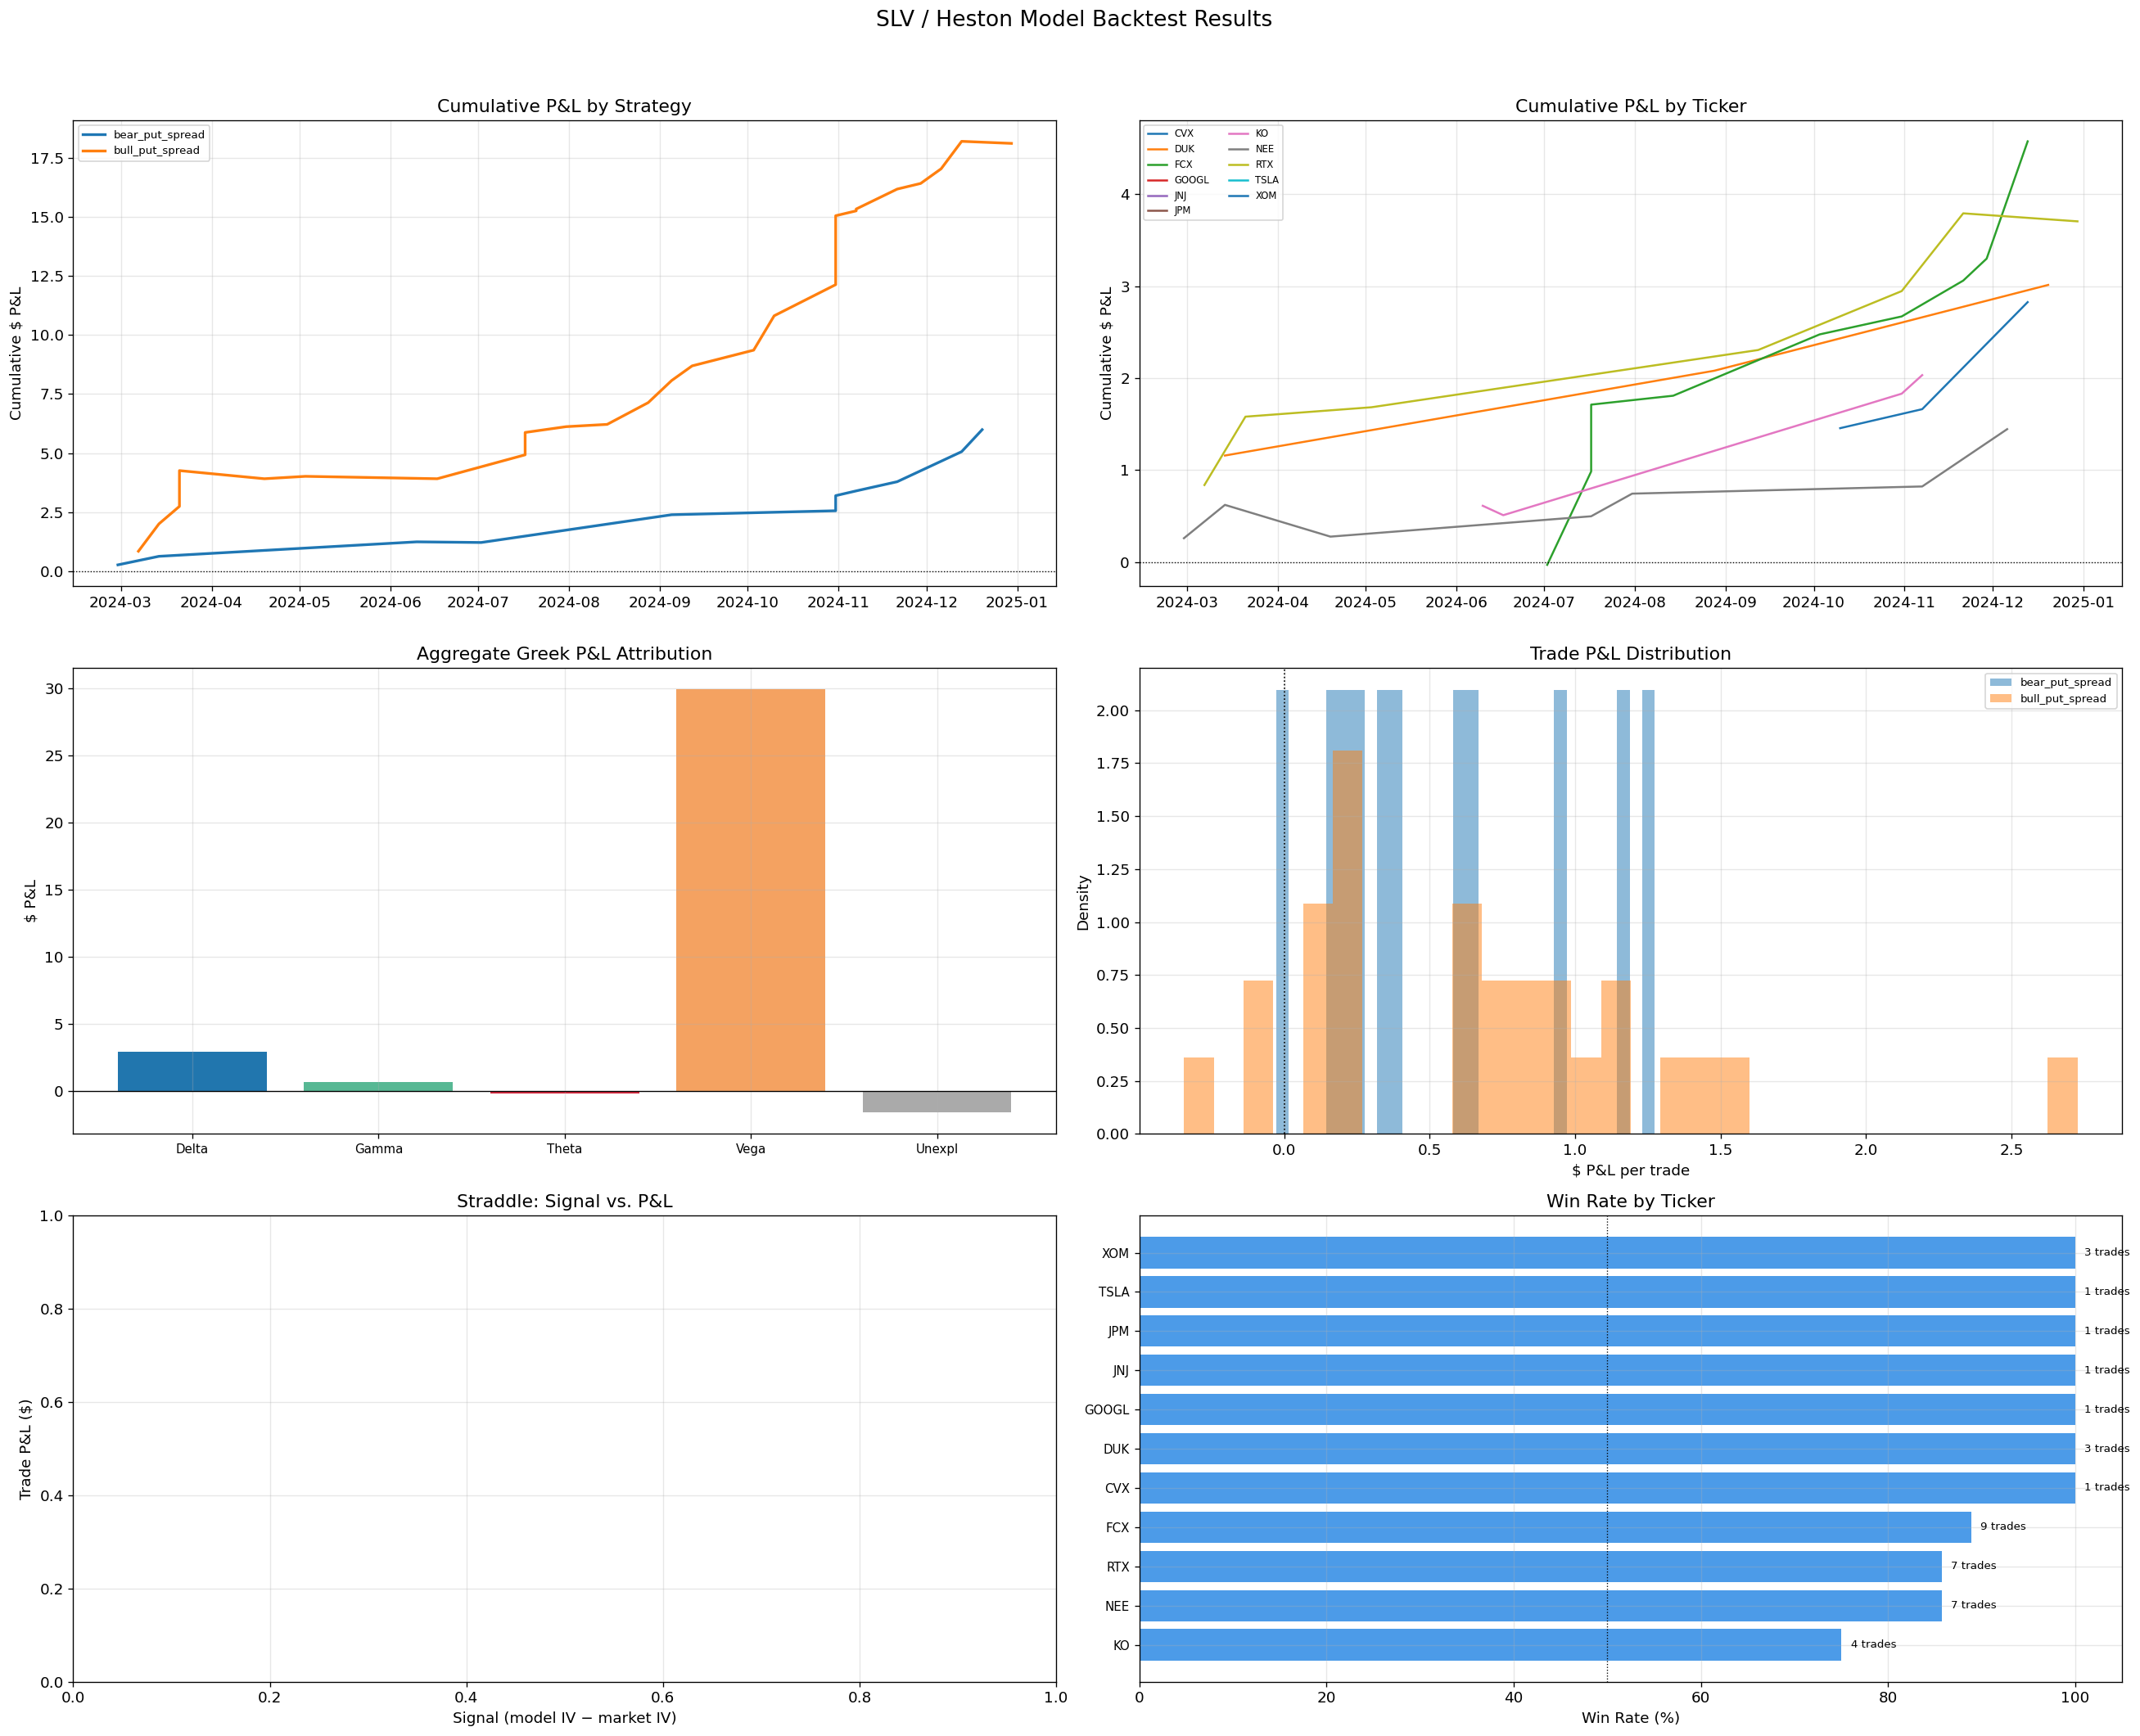

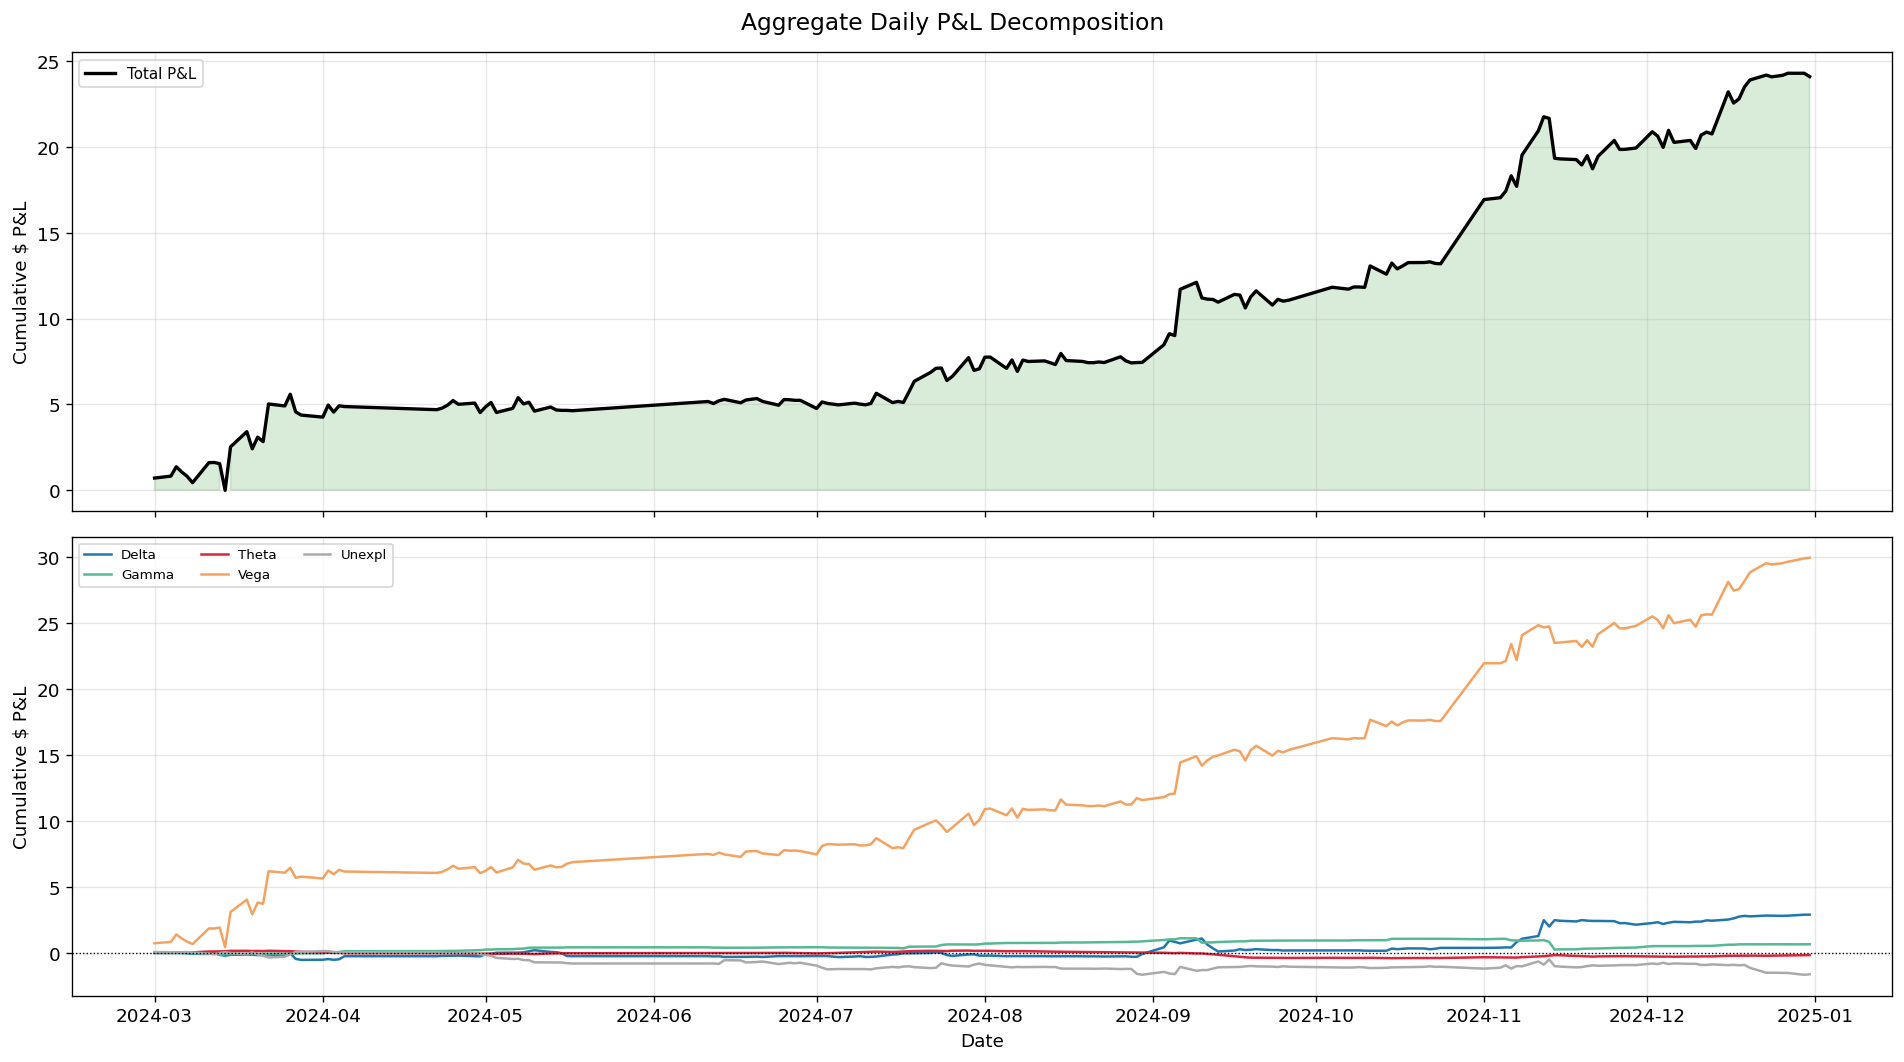


✓ Backtest analysis complete


In [36]:
if all_summaries.empty:
    print("No trades to visualise.")
else:
    fig = plt.figure(figsize=(22, 18))
    fig.suptitle('SLV / Heston Model Backtest Results', fontsize=16, y=0.98)

    # ── (1) Cumulative P&L by strategy ──────────────────────
    ax1 = fig.add_subplot(3, 2, 1)
    for strat, grp in all_summaries.groupby('strategy'):
        cum = grp.sort_values('entry_date')['total_pnl'].cumsum()
        ax1.plot(grp.sort_values('entry_date')['entry_date'].values,
                 cum.values, lw=2, label=strat)
    ax1.axhline(0, c='k', lw=0.8, ls=':')
    ax1.set_title('Cumulative P&L by Strategy')
    ax1.set_ylabel('Cumulative $ P&L')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # ── (2) Cumulative P&L by ticker ────────────────────────
    ax2 = fig.add_subplot(3, 2, 2)
    for tkr, grp in all_summaries.groupby('ticker'):
        cum = grp.sort_values('entry_date')['total_pnl'].cumsum()
        ax2.plot(grp.sort_values('entry_date')['entry_date'].values,
                 cum.values, lw=1.5, label=tkr)
    ax2.axhline(0, c='k', lw=0.8, ls=':')
    ax2.set_title('Cumulative P&L by Ticker')
    ax2.set_ylabel('Cumulative $ P&L')
    ax2.legend(fontsize=7, ncol=2)
    ax2.grid(True, alpha=0.3)

    # ── (3) Greek attribution bar chart ─────────────────────
    ax3 = fig.add_subplot(3, 2, 3)
    attr_data = all_summaries[['cum_delta','cum_gamma','cum_theta',
                                'cum_vega','cum_unexpl']].sum()
    colors = ['#2176AE','#57B894','#D7263D','#F4A261','#AAAAAA']
    ax3.bar(range(5), attr_data.values, color=colors)
    ax3.set_xticks(range(5))
    ax3.set_xticklabels(['Delta','Gamma','Theta','Vega','Unexpl'], fontsize=9)
    ax3.axhline(0, c='k', lw=0.8)
    ax3.set_title('Aggregate Greek P&L Attribution')
    ax3.set_ylabel('$ P&L')
    ax3.grid(True, alpha=0.3)

    # ── (4) Trade P&L distribution ──────────────────────────
    ax4 = fig.add_subplot(3, 2, 4)
    for strat, grp in all_summaries.groupby('strategy'):
        ax4.hist(grp['total_pnl'], bins=30, alpha=0.5, label=strat, density=True)
    ax4.axvline(0, c='k', lw=1, ls=':')
    ax4.set_title('Trade P&L Distribution')
    ax4.set_xlabel('$ P&L per trade')
    ax4.set_ylabel('Density')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    # ── (5) Signal vs. P&L scatter ──────────────────────────
    ax5 = fig.add_subplot(3, 2, 5)
    straddles = all_summaries[all_summaries['strategy'] == 'straddle']
    if not straddles.empty:
        c = np.where(straddles['win'], '#57B894', '#D7263D')
        ax5.scatter(straddles['signal'], straddles['total_pnl'],
                    c=c, s=25, alpha=0.6, edgecolors='k', linewidths=0.3)
        ax5.axhline(0, c='k', lw=0.8, ls=':')
        ax5.axvline(0, c='grey', lw=0.6, ls=':')
        # regression line
        if len(straddles) > 5:
            z = np.polyfit(straddles['signal'], straddles['total_pnl'], 1)
            xs = np.linspace(straddles['signal'].min(), straddles['signal'].max(), 50)
            ax5.plot(xs, np.polyval(z, xs), 'b--', lw=1.5,
                     label=f'slope={z[0]:.1f}')
            ax5.legend(fontsize=8)
    ax5.set_title('Straddle: Signal vs. P&L')
    ax5.set_xlabel('Signal (model IV − market IV)')
    ax5.set_ylabel('Trade P&L ($)')
    ax5.grid(True, alpha=0.3)

    # ── (6) Win rate by ticker ──────────────────────────────
    ax6 = fig.add_subplot(3, 2, 6)
    wr_by_tkr = (all_summaries.groupby('ticker')['win']
                 .agg(['mean','count'])
                 .sort_values('mean', ascending=True))
    bars = ax6.barh(range(len(wr_by_tkr)), wr_by_tkr['mean'] * 100,
                    color='#4C9BE8')
    ax6.set_yticks(range(len(wr_by_tkr)))
    ax6.set_yticklabels(wr_by_tkr.index, fontsize=9)
    ax6.axvline(50, c='k', lw=0.8, ls=':')
    ax6.set_xlabel('Win Rate (%)')
    ax6.set_title('Win Rate by Ticker')
    for i, (wr, n) in enumerate(zip(wr_by_tkr['mean'], wr_by_tkr['count'])):
        ax6.text(wr * 100 + 1, i, f'{n} trades', va='center', fontsize=8)
    ax6.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # ── Daily P&L time-series (aggregate across all trades) ─
    if not all_daily.empty:
        fig2, axes2 = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
        fig2.suptitle('Aggregate Daily P&L Decomposition', fontsize=14)

        daily_agg = (all_daily
                     .groupby('date')[['dP','delta_pnl','gamma_pnl',
                                       'theta_pnl','vega_pnl','unexpl']]
                     .sum()
                     .sort_index())

        ax = axes2[0]
        ax.plot(daily_agg.index, daily_agg['dP'].cumsum(),
                c='k', lw=2, label='Total P&L')
        ax.fill_between(daily_agg.index,
                        daily_agg['dP'].cumsum(), 0,
                        where=daily_agg['dP'].cumsum() >= 0,
                        alpha=0.15, color='green')
        ax.fill_between(daily_agg.index,
                        daily_agg['dP'].cumsum(), 0,
                        where=daily_agg['dP'].cumsum() < 0,
                        alpha=0.15, color='red')
        ax.set_ylabel('Cumulative $ P&L')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        ax = axes2[1]
        cols_plot = ['delta_pnl','gamma_pnl','theta_pnl','vega_pnl','unexpl']
        colors_p  = ['#2176AE','#57B894','#D7263D','#F4A261','#AAAAAA']
        for col, clr in zip(cols_plot, colors_p):
            ax.plot(daily_agg.index, daily_agg[col].cumsum(),
                    lw=1.5, label=col.replace('_pnl','').title(), c=clr)
        ax.axhline(0, c='k', lw=0.8, ls=':')
        ax.set_ylabel('Cumulative $ P&L')
        ax.set_xlabel('Date')
        ax.legend(fontsize=8, ncol=3)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

print("\n✓ Backtest analysis complete")